# Sleep Stage Classification — EOG-R + ResNet1D-LSTM (Deep Learning)


In [2]:
import os
import numpy as np
import mne
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, cohen_kappa_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from scipy.signal import butter, filtfilt
from tqdm import tqdm
import xml.etree.ElementTree as ET


In [3]:
import subprocess
subprocess.run(['pip', 'install', 'pyedflib'], check=True)

CompletedProcess(args=['pip', 'install', 'pyedflib'], returncode=0)

## Bandpass Filter (0.3–35 Hz)


In [4]:
# ======================================
# Bandpass Filter for Signal Processing
# ======================================

def bandpass_filter(
    signal,
    fs,
    lowcut=0.3,
    highcut=35,
    order=4
):

    # Calculate Nyquist frequency
    nyquist = 0.5 * fs

    # Normalize cutoff frequencies
    low = lowcut / nyquist
    high = highcut / nyquist

    # Create Butterworth bandpass filter
    b, a = butter(
        order,
        [low, high],
        btype='band'
    )

    # Apply filter to the signal
    filtered_signal = filtfilt(
        b,
        a,
        signal
    )

    # Convert output to float32
    return filtered_signal.astype(np.float32)

## Load EOG + Apply Filter


In [5]:
# ======================================
# Load and Preprocess EOG-R Signal
# ======================================

import pyedflib

def load_eog(file_path):

    # Open EDF file
    with pyedflib.EdfReader(file_path) as f:

        # Get channel names
        ch_names = f.getSignalLabels()

        # Get sampling frequencies
        fs_list = f.getSampleFrequencies()

        # Find EOG-R channel index
        eog_r_idx = next(
            (
                i for i, ch in enumerate(ch_names)
                if ch.strip() == 'EOG-R'
            ),
            None
        )

        # Check if EOG-R channel exists
        if eog_r_idx is None:

            raise ValueError(
                f"Channel EOG-R not found in {ch_names}"
            )

        # Read EOG-R signal
        eog = f.readSignal(
            eog_r_idx
        ).astype(np.float32)

        # Get sampling frequency
        fs = int(fs_list[eog_r_idx])

    # Apply bandpass filter
    eog = bandpass_filter(eog, fs)

    # Return filtered signal and sampling rate
    return eog.astype(np.float32), fs

## Create Epochs (30 sec)


In [6]:
# ======================================
# Split Signal into 30-Second Epochs
# ======================================

def create_epochs(
    signal,
    fs,
    epoch_duration=30
):

    # Number of samples in one epoch
    samples = fs * epoch_duration

    # Total number of complete epochs
    num_epochs = len(signal) // samples

    # Split signal into epochs
    epochs = np.array([
        signal[i * samples:(i + 1) * samples]
        for i in range(num_epochs)
    ])

    # Return epochs array
    return epochs

## Load XML Labels


In [7]:
# ======================================
# Load Sleep Stage Labels from XML File
# ======================================

def load_labels(xml_file):

    # Parse XML annotation file
    tree = ET.parse(xml_file)
    root = tree.getroot()

    # Store labels
    labels = []

    # Loop through all scored events
    for event in root.iter('ScoredEvent'):

        # Get event information
        concept = event.find('EventConcept')
        duration = event.find('Duration')

        # Skip invalid events
        if concept is None or duration is None:
            continue

        stage = concept.text
        duration = float(duration.text)

        # Ignore unrelated events
        if (
            "Stage" not in stage
            and "REM" not in stage
            and "Wake" not in stage
        ):
            continue

        # Number of 30-second epochs
        num_epochs = int(duration / 30)

        # ======================================
        # Convert Sleep Stages to Numeric Labels
        # ======================================

        if 'Wake' in stage:
            label = 0

        elif 'Stage 1' in stage:
            label = 1

        elif 'Stage 2' in stage:
            label = 2

        elif (
            'Stage 3' in stage
            or 'Stage 4' in stage
        ):
            label = 3

        elif 'REM' in stage:
            label = 4

        else:
            continue

        # Add label for each epoch
        labels.extend([label] * num_epochs)

    # Return labels as NumPy array
    return np.array(labels)

## Normalize


In [8]:
# ======================================
# Normalize Epoch Signals
# ======================================

def normalize(epochs):

    # Create normalization object
    scaler = StandardScaler()

    # Reshape data for scaler
    reshaped = epochs.reshape(-1, 1)

    # Apply normalization
    normalized = scaler.fit_transform(reshaped)

    # Restore original shape
    normalized = normalized.reshape(epochs.shape)

    # Return normalized epochs
    return normalized

## Create Sequences Inside Each Subject Only ✅


In [9]:
# ======================================
# Create Sequences for One Subject
# ======================================

def create_sequences_per_subject(
    epochs,
    labels,
    seq_len=10
):
    """
    Create sequences inside one subject only.

    This prevents mixing epochs
    from different subjects.
    """

    X_seq = []
    y_seq = []

    # Loop through epochs
    for i in range(len(epochs) - seq_len):

        # Input sequence
        # Example: 10 consecutive epochs
        X_seq.append(
            epochs[i:i + seq_len]
        )

        # Target label
        # Label of the next epoch
        y_seq.append(
            labels[i + seq_len]
        )

    # Convert to NumPy arrays
    return (
        np.array(X_seq),
        np.array(y_seq)
    )

## Load Dataset — Subject by Subject ✅


In [10]:
# ======================================
# Load and Process All Subjects
# ======================================

def load_all_subjects(
    data_path,
    ann_path,
    seq_len=10
):
    """
    Load all subjects separately.

    Each subject contains:
    (X_seq, y_seq)
    """

    # Store all processed subjects
    subjects = []

    # Get all EDF files
    files = sorted([
        f for f in os.listdir(data_path)
        if f.endswith('.edf')
    ])

    # ======================================
    # Process Each Subject
    # ======================================

    for file in files:

        # Build file paths
        edf_path = os.path.join(
            data_path,
            file
        )

        xml_path = os.path.join(
            ann_path,
            file.replace('.edf', '-nsrr.xml')
        )

        # Skip files without annotation
        if not os.path.exists(xml_path):

            print(
                f"Skipped (no annotation): {file}"
            )

            continue

        try:
            # ======================================
            # Load Signal and Labels
            # ======================================

            signal, fs = load_eog(edf_path)

            epochs = create_epochs(
                signal,
                fs
            )

            labels = load_labels(xml_path)

            # ======================================
            # Align Epochs and Labels
            # ======================================

            min_len = min(
                len(epochs),
                len(labels)
            )

            epochs = epochs[:min_len]
            labels = labels[:min_len]

            # ======================================
            # Normalize Epochs
            # ======================================

            epochs = normalize(epochs)

            # ======================================
            # Create Sequences
            # ======================================

            X_seq, y_seq = create_sequences_per_subject(
                epochs,
                labels,
                seq_len
            )

            # Store subject data
            subjects.append(
                (X_seq, y_seq)
            )

            print(
                f"Loaded: {file} — "
                f"{len(epochs)} epochs → "
                f"{len(X_seq)} sequences"
            )

        except Exception as e:

            print(
                f"Skipped {file}: {e}"
            )

    # Return all subjects
    return subjects

##  Split Data at the Subject Level ✅ (80% Train / 10% Val / 10% Test)


In [11]:
# ======================================
# Split Subjects into Train / Val / Test
# ======================================

def split_subjects(
    subjects,
    train_ratio=0.8,
    val_ratio=0.1
):
    """
    Split data at the subject level:

    - 80% Train
    - 10% Validation
    - 10% Test

    This prevents the same subject
    from appearing in multiple sets.
    """

    # Total number of subjects
    n = len(subjects)

    # Calculate split sizes
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    # Remaining subjects go to test set

    # ======================================
    # Split Subjects
    # ======================================

    train_subjects = subjects[:n_train]

    val_subjects = subjects[
        n_train:n_train + n_val
    ]

    test_subjects = subjects[
        n_train + n_val:
    ]

    # ======================================
    # Combine Subject Data
    # ======================================

    def concat(subj_list):

        # Merge all sequences
        X = np.concatenate([
            s[0] for s in subj_list
        ])

        # Merge all labels
        y = np.concatenate([
            s[1] for s in subj_list
        ])

        return X, y

    # Create datasets
    X_train, y_train = concat(train_subjects)

    X_val, y_val = concat(val_subjects)

    X_test, y_test = concat(test_subjects)

    # ======================================
    # Print Dataset Information
    # ======================================

    print(
        f"Train: {len(train_subjects)} subjects "
        f"→ {len(X_train)} sequences "
        f"({train_ratio * 100:.0f}%)"
    )

    print(
        f"Val  : {len(val_subjects)} subjects "
        f"→ {len(X_val)} sequences "
        f"({val_ratio * 100:.0f}%)"
    )

    print(
        f"Test : {len(test_subjects)} subjects "
        f"→ {len(X_test)} sequences "
        f"({(1 - train_ratio - val_ratio) * 100:.0f}%)"
    )

    # Return split datasets
    return (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test
    )

## Dataset Class


In [12]:
# ======================================
# Custom Dataset for Sleep Staging
# ======================================

class SleepDataset(Dataset):
    """
    Dataset format:

    X shape:
    (samples, seq_len, timesteps)

    Each epoch will be processed
    separately inside the CNN.
    """

    def __init__(self, X, y):

        # Convert data to PyTorch tensors
        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):

        # Return total number of samples
        return len(self.X)

    def __getitem__(self, idx):

        # Return one sample and its label
        return self.X[idx], self.y[idx]

## ResNet1D + Attention + LSTM Model (Pre-trained style)


In [13]:
# ================================================================
# ResNet1D Encoder — Lightweight Version
# ================================================================

class ResidualBlock1D(nn.Module):
    """
    Residual Block with skip connection.

    Skip connections help reduce
    the vanishing gradient problem.
    """

    def __init__(
        self,
        in_ch,
        out_ch,
        kernel_size=7,
        stride=1,
        dropout=0.2
    ):
        super().__init__()

        # Padding size
        pad = kernel_size // 2

        # First convolution layer
        self.conv1 = nn.Conv1d(
            in_ch,
            out_ch,
            kernel_size,
            stride=stride,
            padding=pad,
            bias=False
        )

        self.bn1 = nn.BatchNorm1d(out_ch)

        # Second convolution layer
        self.conv2 = nn.Conv1d(
            out_ch,
            out_ch,
            kernel_size,
            padding=pad,
            bias=False
        )

        self.bn2 = nn.BatchNorm1d(out_ch)

        # Dropout layer
        self.drop = nn.Dropout(dropout)

        # Activation function
        self.relu = nn.ReLU(inplace=True)

        # Shortcut connection
        if in_ch != out_ch or stride != 1:

            self.shortcut = nn.Sequential(
                nn.Conv1d(
                    in_ch,
                    out_ch,
                    1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm1d(out_ch)
            )

        else:
            self.shortcut = nn.Identity()

    def forward(self, x):

        # Main path
        out = self.relu(
            self.bn1(
                self.conv1(x)
            )
        )

        out = self.drop(out)

        out = self.bn2(
            self.conv2(out)
        )

        # Add shortcut connection
        out = out + self.shortcut(x)

        return self.relu(out)


# ================================================================
# ResNet1D Encoder
# ================================================================

class ResNet1DEncoder(nn.Module):
    """
    Lightweight ResNet1D encoder.

    layer3 was removed to reduce:
    - Memory usage
    - Model complexity
    """

    def __init__(
        self,
        out_dim=128,
        dropout=0.2
    ):
        super().__init__()

        # ======================================
        # Initial Feature Extraction
        # ======================================

        self.stem = nn.Sequential(

            nn.Conv1d(
                1,
                32,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False
            ),

            nn.BatchNorm1d(32),

            nn.ReLU(inplace=True),

            nn.MaxPool1d(
                3,
                stride=2,
                padding=1
            )
        )

        # ======================================
        # Residual Layer 1
        # ======================================

        self.layer1 = nn.Sequential(

            ResidualBlock1D(
                32,
                64,
                kernel_size=7,
                dropout=dropout
            ),

            ResidualBlock1D(
                64,
                64,
                kernel_size=7,
                dropout=dropout
            ),
        )

        # ======================================
        # Residual Layer 2
        # ======================================

        self.layer2 = nn.Sequential(

            ResidualBlock1D(
                64,
                out_dim,
                kernel_size=5,
                dropout=dropout
            ),

            ResidualBlock1D(
                out_dim,
                out_dim,
                kernel_size=5,
                dropout=dropout
            ),
        )

        # Global average pooling
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):

        # Initial feature extraction
        x = self.stem(x)

        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)

        # Output shape:
        # (batch, out_dim)
        return self.pool(x).squeeze(-1)


# ================================================================
# Temporal Attention Layer
# ================================================================

class TemporalAttention(nn.Module):
    """
    Self-attention layer for LSTM outputs.
    """

    def __init__(self, hidden_dim):
        super().__init__()

        self.attn = nn.Linear(
            hidden_dim,
            1
        )

    def forward(self, lstm_out):

        # Attention scores
        scores = self.attn(
            lstm_out
        ).squeeze(-1)

        # Attention weights
        weights = torch.softmax(
            scores,
            dim=1
        )

        # Weighted context vector
        context = (
            lstm_out *
            weights.unsqueeze(-1)
        ).sum(dim=1)

        return context


# ================================================================
# Sleep Staging Model
# ================================================================

class SleepModel(nn.Module):
    """
    ResNet1D + Bi-LSTM + Temporal Attention

    Improvements:
    - Lightweight encoder
    - Lower memory usage
    - Better temporal learning
    """

    def __init__(
        self,
        resnet_out=128,
        lstm_hidden=128,
        lstm_layers=2,
        num_classes=5,
        dropout=0.3
    ):
        super().__init__()

        # ======================================
        # Feature Encoder
        # ======================================

        self.encoder = ResNet1DEncoder(
            out_dim=resnet_out,
            dropout=dropout
        )

        # ======================================
        # Bidirectional LSTM
        # ======================================

        self.lstm = nn.LSTM(
            input_size=resnet_out,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        # ======================================
        # Attention Layer
        # ======================================

        self.attention = TemporalAttention(
            lstm_hidden * 2
        )

        # ======================================
        # Final Classifier
        # ======================================

        self.classifier = nn.Sequential(

            nn.Linear(
                lstm_hidden * 2,
                128
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(128, 64),

            nn.ReLU(),

            nn.Dropout(dropout * 0.5),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        # Input shape:
        # (batch, seq_len, timesteps)

        batch, seq_len, timesteps = x.shape

        # ======================================
        # Apply ResNet1D on Each Epoch
        # ======================================

        x = x.view(
            batch * seq_len,
            1,
            timesteps
        )

        x = self.encoder(x)

        x = x.view(
            batch,
            seq_len,
            -1
        )

        # ======================================
        # Apply Bi-LSTM
        # ======================================

        lstm_out, _ = self.lstm(x)

        # ======================================
        # Apply Temporal Attention
        # ======================================

        context = self.attention(lstm_out)

        # ======================================
        # Final Prediction
        # ======================================

        return self.classifier(context)

## Training Function — Focal Loss + Cosine LR


In [14]:
# ================================================================
# Focal Loss for Imbalanced Data
# Better than CrossEntropy for minority classes
# ================================================================

class FocalLoss(nn.Module):

    def __init__(
        self,
        gamma=2.0,
        weight=None
    ):
        super().__init__()

        self.gamma = gamma
        self.weight = weight

    def forward(
        self,
        logits,
        targets
    ):

        # Compute CrossEntropy loss
        ce_loss = F.cross_entropy(
            logits,
            targets,
            weight=self.weight,
            reduction="none"
        )

        # Probability of correct prediction
        pt = torch.exp(-ce_loss)

        # Apply focal scaling
        focal = (
            (1 - pt) ** self.gamma
        ) * ce_loss

        # Return mean loss
        return focal.mean()


# ================================================================
# Train the Sleep Staging Model
# ================================================================

def train_model(
    model,
    train_loader,
    val_loader,
    weights,
    epochs=50
):

    # ======================================
    # Device Setup
    # ======================================

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print("Using:", device)

    model.to(device)

    # ======================================
    # Optimizer
    # ======================================

    optimizer = optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )

    # ======================================
    # Learning Rate Scheduler
    # ======================================

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=1e-6
    )

    # ======================================
    # Loss Function
    # ======================================

    criterion = FocalLoss(
        gamma=2.0,
        weight=weights.to(device)
    )

    # ======================================
    # Mixed Precision Training
    # Saves memory and speeds up training
    # ======================================

    use_amp = torch.cuda.is_available()

    scaler = torch.cuda.amp.GradScaler(
        enabled=use_amp
    )

    # ======================================
    # Early Stopping Settings
    # ======================================

    best_f1 = 0.0

    patience_counter = 0

    early_stop_patience = 10

    # ======================================
    # Store Training History
    # ======================================

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    # ============================================================
    # Training Loop
    # ============================================================

    for epoch in range(epochs):

        # ======================================
        # TRAINING
        # ======================================

        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for X, y in tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{epochs}"
        ):

            # Move batch to device
            X, y = X.to(device), y.to(device)

            # Reset gradients
            optimizer.zero_grad()

            # ======================================
            # Forward Pass with Mixed Precision
            # ======================================

            with torch.cuda.amp.autocast(
                enabled=use_amp
            ):

                outputs = model(X)

                loss = criterion(
                    outputs,
                    y
                )

            # Backpropagation
            scaler.scale(loss).backward()

            # Prevent gradient explosion
            scaler.unscale_(optimizer)

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            # Update weights
            scaler.step(optimizer)

            scaler.update()

            # Training statistics
            total_loss += loss.item()

            correct += (
                torch.argmax(outputs, 1) == y
            ).sum().item()

            total += y.size(0)

        # Average training results
        train_loss = total_loss / len(train_loader)

        train_acc = correct / total

        # ======================================
        # VALIDATION
        # ======================================

        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        all_preds = []
        all_labels = []

        with torch.no_grad():

            for X, y in val_loader:

                # Move data to device
                X, y = X.to(device), y.to(device)

                # Validation forward pass
                with torch.cuda.amp.autocast(
                    enabled=use_amp
                ):

                    outputs = model(X)

                    loss = criterion(
                        outputs,
                        y
                    )

                # Validation statistics
                val_loss += loss.item()

                p = torch.argmax(outputs, 1)

                correct += (
                    p == y
                ).sum().item()

                total += y.size(0)

                all_preds.extend(
                    p.cpu().numpy()
                )

                all_labels.extend(
                    y.cpu().numpy()
                )

        # Average validation results
        val_loss /= len(val_loader)

        val_acc = correct / total

        # Compute Macro F1-score
        val_f1 = f1_score(
            all_labels,
            all_preds,
            average="macro",
            zero_division=0
        )

        # Update learning rate
        scheduler.step()

        # Save training history
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # ======================================
        # Print Epoch Results
        # ======================================

        print(
            f"Epoch {epoch+1}: "
            f"Train Loss={train_loss:.4f} "
            f"Acc={train_acc:.4f} | "
            f"Val Loss={val_loss:.4f} "
            f"Acc={val_acc:.4f} "
            f"F1={val_f1:.4f} | "
            f"LR={scheduler.get_last_lr()[0]:.2e}"
        )

        # ======================================
        # Save Best Model
        # ======================================

        if val_f1 > best_f1:

            best_f1 = val_f1

            patience_counter = 0

            torch.save(
                model.state_dict(),
                "best.pth"
            )

            print(
                f"✅ Saved best model "
                f"(F1={val_f1:.4f})"
            )

        else:

            patience_counter += 1

            # Early stopping
            if patience_counter >= early_stop_patience:

                print("Early stopping.")

                break

    # Return training history
    return (
        train_losses,
        val_losses,
        train_accs,
        val_accs
    )

## Evaluation


In [15]:
# ================================================================
# Evaluate the Trained Model
# ================================================================

def evaluate(model, test_loader):

    # ======================================
    # Device Setup
    # ======================================

    device = torch.device(
        'cuda'
        if torch.cuda.is_available()
        else 'cpu'
    )

    # ======================================
    # Load Best Saved Model
    # ======================================

    model.load_state_dict(
        torch.load(
            'best.pth',
            map_location=device
        )
    )

    # Move model to device
    model.to(device)

    # Set evaluation mode
    model.eval()

    # Store predictions and labels
    preds = []
    labels = []

    # ======================================
    # Evaluation Loop
    # ======================================

    with torch.no_grad():

        for X, y in test_loader:

            # Move input to device
            X = X.to(device)

            # Forward pass
            outputs = model(X)

            # Predicted class
            p = torch.argmax(
                outputs,
                1
            ).cpu().numpy()

            # Store predictions
            preds.extend(p)

            # Store true labels
            labels.extend(y.numpy())

    # ======================================
    # Sleep Stage Names
    # ======================================

    target_names = [
        'Wake',
        'Stage 1',
        'Stage 2',
        'Stage 3/4',
        'REM'
    ]

    # ======================================
    # Print Classification Report
    # ======================================

    print(
        classification_report(
            labels,
            preds,
            target_names=target_names
        )
    )

    # Print Macro F1-score
    print(
        'Macro F1  :',
        round(
            f1_score(
                labels,
                preds,
                average='macro'
            ),
            4
        )
    )

    # Print Cohen Kappa score
    print(
        'Cohen Kappa:',
        round(
            cohen_kappa_score(
                labels,
                preds
            ),
            4
        )
    )

    # Return predictions and labels
    return preds, labels

## Plot Training Curves


In [16]:
# ================================================================
# Plot Training and Validation Curves
# ================================================================

def plot_results(
    train_losses,
    val_losses,
    train_accs,
    val_accs
):

    # Create figure
    plt.figure(figsize=(12, 5))

    # ======================================
    # Loss Curves
    # ======================================

    plt.subplot(1, 2, 1)

    # Plot training loss
    plt.plot(
        train_losses,
        label='Train Loss'
    )

    # Plot validation loss
    plt.plot(
        val_losses,
        label='Val Loss'
    )

    # Plot settings
    plt.legend()

    plt.title('Loss Curve')

    plt.xlabel('Epoch')

    plt.ylabel('Loss')

    # ======================================
    # Accuracy Curves
    # ======================================

    plt.subplot(1, 2, 2)

    # Plot training accuracy
    plt.plot(
        train_accs,
        label='Train Acc'
    )

    # Plot validation accuracy
    plt.plot(
        val_accs,
        label='Val Acc'
    )

    # Plot settings
    plt.legend()

    plt.title('Accuracy Curve')

    plt.xlabel('Epoch')

    plt.ylabel('Accuracy')

    # Adjust layout
    plt.tight_layout()

    # Save figure
    plt.savefig(
        'training_curves.png',
        dpi=150,
        bbox_inches='tight'
    )

    # Show figure
    plt.show()

## Plot Confusion Matrix


In [17]:
# ================================================================
# Plot Confusion Matrix
# ================================================================

def plot_confusion_matrix(
    labels,
    preds
):

    # Sleep stage names
    class_names = [
        'Wake',
        'Stage 1',
        'Stage 2',
        'Stage 3/4',
        'REM'
    ]

    # ======================================
    # Compute Confusion Matrices
    # ======================================

    # Raw confusion matrix
    cm = confusion_matrix(
        labels,
        preds
    )

    # Normalized confusion matrix
    cm_norm = cm.astype('float') / cm.sum(
        axis=1,
        keepdims=True
    )

    # ======================================
    # Create Figure
    # ======================================

    fig, axes = plt.subplots(
        1, 2,
        figsize=(16, 6)
    )

    # ======================================
    # Raw Confusion Matrix
    # ======================================

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[0],
        linewidths=0.5
    )

    axes[0].set_title(
        'Confusion Matrix — Raw Counts',
        fontsize=14,
        fontweight='bold'
    )

    axes[0].set_xlabel(
        'Predicted Label'
    )

    axes[0].set_ylabel(
        'True Label'
    )

    # ======================================
    # Normalized Confusion Matrix
    # ======================================

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='YlOrRd',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[1],
        linewidths=0.5,
        vmin=0,
        vmax=1
    )

    axes[1].set_title(
        'Confusion Matrix — Normalized (Recall)',
        fontsize=14,
        fontweight='bold'
    )

    axes[1].set_xlabel(
        'Predicted Label'
    )

    axes[1].set_ylabel(
        'True Label'
    )

    # ======================================
    # Main Figure Title
    # ======================================

    plt.suptitle(
        'Sleep Stage Classification Results',
        fontsize=16,
        fontweight='bold'
    )

    # Adjust layout
    plt.tight_layout()

    # Save figure
    plt.savefig(
        'confusion_matrix.png',
        dpi=150,
        bbox_inches='tight'
    )

    # Show figure
    plt.show()

# ▶️ Run the Full Sleep Staging Pipeline


In [18]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU — using CPU')


True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [19]:
# ================================================================
# Dataset Paths and Configuration
# ================================================================

# Update paths based on your computer
data_path = r"C:\Users\Laptop\Desktop\Project\Signals"

ann_path = r"C:\Users\Laptop\Desktop\Project\Annotations"

# Number of epochs in each sequence
SEQ_LEN = 10

## 📋 Display All Channels in the EDF File

📂 File: mesa-sleep-0001.edf
Number of channels: 27
Recording duration: 12.00 hours (43199 seconds)

#     Channel Name         Fs (Hz)      Samples     
----------------------------------------------------
0     EKG                  256          11,058,944  
1     EOG-L                256          11,058,944  
2     EOG-R                256          11,058,944  
3     EMG                  256          11,058,944  
4     EEG1                 256          11,058,944  
5     EEG2                 256          11,058,944  
6     EEG3                 256          11,058,944  
7     Pres                 32           1,382,368   
8     Flow                 32           1,382,368   
9     Snore                32           1,382,368   
10    Thor                 32           1,382,368   
11    Abdo                 32           1,382,368   
12    Leg                  32           1,382,368   
13    Therm                32           1,382,368   
14    Pos                  32           1,382,368   

C:\Users\Laptop\AppData\Local\Temp\ipykernel_7548\2877506135.py:216: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


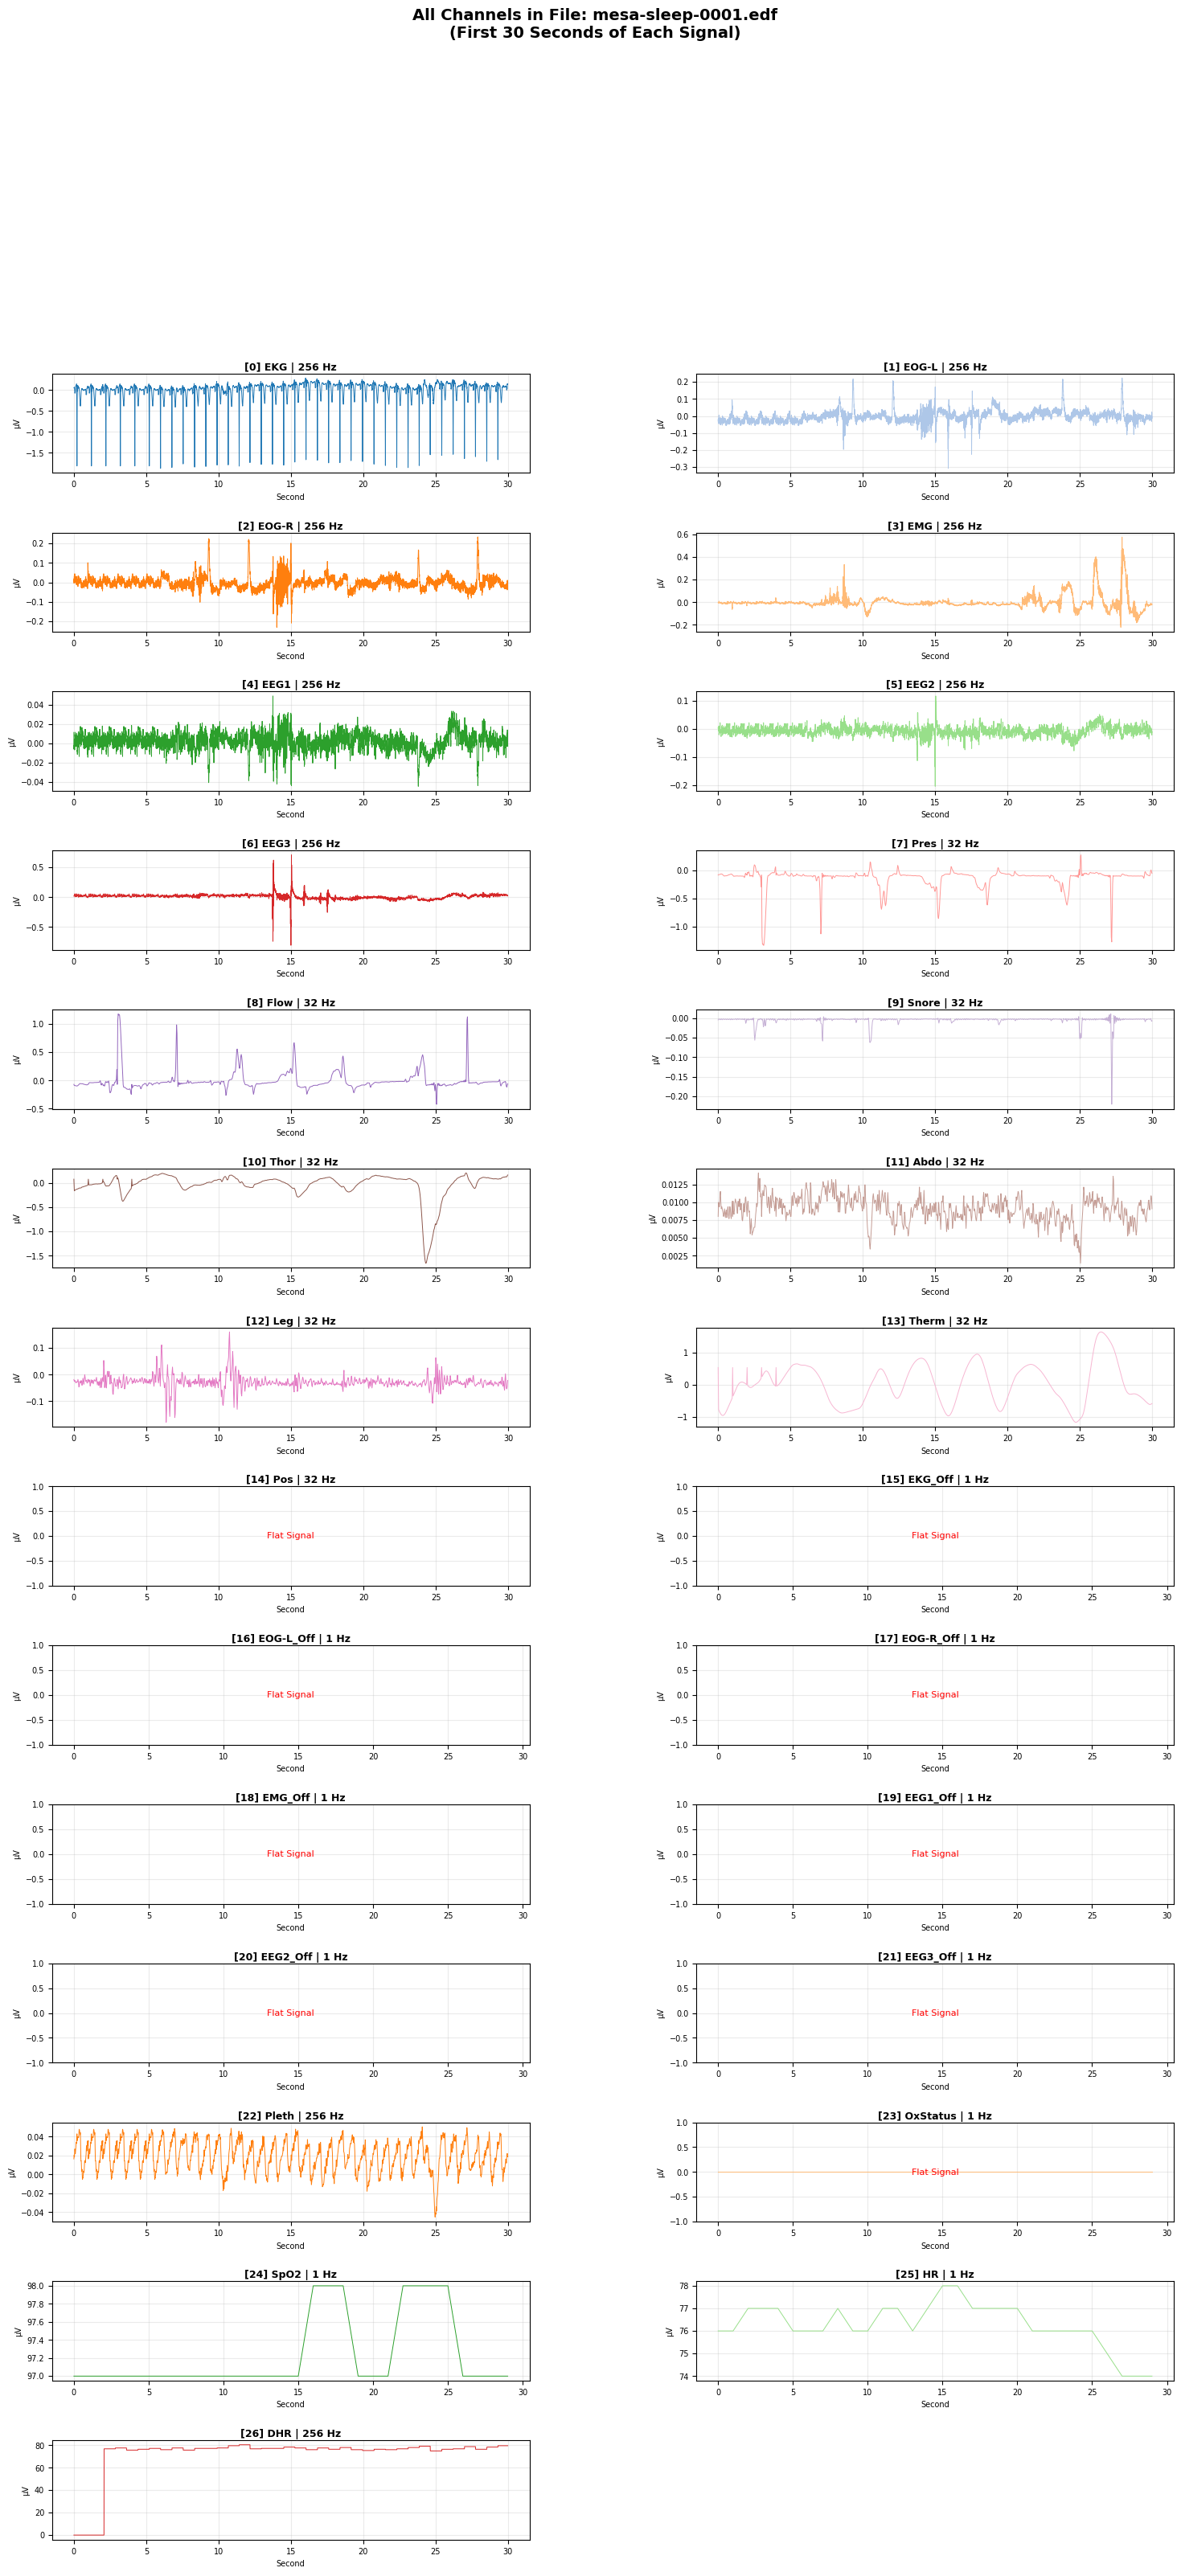


✅ Figure saved as: all_channels.png


In [20]:
# ================================================================
# Display All Channels from the First EDF File
# Show:
# - Channel name
# - Sampling frequency
# - Signal waveform
# ================================================================

import pyedflib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ======================================
# Load First EDF File
# ======================================

files = sorted([
    f for f in os.listdir(data_path)
    if f.endswith('.edf')
])

sample_file = os.path.join(
    data_path,
    files[0]
)

print(f'📂 File: {files[0]}')
print('=' * 60)

# ======================================
# Read EDF File
# ======================================

with pyedflib.EdfReader(sample_file) as f:

    # Get channel names
    ch_names = f.getSignalLabels()

    # Get sampling frequencies
    fs_list = f.getSampleFrequencies()

    # Total number of channels
    n_channels = f.signals_in_file

    # Recording duration in seconds
    duration_s = f.getFileDuration()

    print(f'Number of channels: {n_channels}')

    print(
        f'Recording duration: '
        f'{duration_s / 3600:.2f} hours '
        f'({duration_s:.0f} seconds)'
    )

    print()

    # ======================================
    # Print Channels Table
    # ======================================

    print(
        f'{"#":<5} '
        f'{"Channel Name":<20} '
        f'{"Fs (Hz)":<12} '
        f'{"Samples":<12}'
    )

    print('-' * 52)

    # Store signals
    signals = []

    for i in range(n_channels):

        # Read signal
        sig = f.readSignal(i).astype(np.float32)

        signals.append(sig)

        # Print channel information
        print(
            f'{i:<5} '
            f'{ch_names[i]:<20} '
            f'{int(fs_list[i]):<12} '
            f'{len(sig):<12,}'
        )

# ======================================
# Plot Settings
# ======================================

show_sec = 30   # Display first 30 seconds

# Grid layout
n_cols = 2

n_rows = (
    n_channels + n_cols - 1
) // n_cols

# Create figure
fig = plt.figure(
    figsize=(18, n_rows * 2.5)
)

# Grid specification
gs = gridspec.GridSpec(
    n_rows,
    n_cols,
    figure=fig,
    hspace=0.6,
    wspace=0.35
)

# Different colors for channels
colors = plt.cm.tab20.colors

# ======================================
# Plot Each Channel
# ======================================

for i in range(n_channels):

    # Grid position
    row, col = divmod(i, n_cols)

    ax = fig.add_subplot(gs[row, col])

    sig = signals[i]

    fs = int(fs_list[i])

    # Number of displayed samples
    n = min(
        show_sec * fs,
        len(sig)
    )

    # Time axis
    t = np.arange(n) / fs

    # Plot signal
    ax.plot(
        t,
        sig[:n],
        color=colors[i % len(colors)],
        linewidth=0.7
    )

    # Plot title
    ax.set_title(
        f'[{i}] {ch_names[i].strip()} | {fs} Hz',
        fontsize=9,
        fontweight='bold',
        pad=3
    )

    # Axis labels
    ax.set_xlabel(
        'Second',
        fontsize=7
    )

    ax.set_ylabel(
        'µV',
        fontsize=7
    )

    # Tick size
    ax.tick_params(labelsize=7)

    # Add grid
    ax.grid(True, alpha=0.25)

    # Handle flat signals
    if sig[:n].std() < 1e-6:

        ax.set_ylim(-1, 1)

        ax.text(
            0.5,
            0.5,
            'Flat Signal',
            transform=ax.transAxes,
            ha='center',
            va='center',
            color='red',
            fontsize=8
        )

# ======================================
# Hide Empty Subplot
# ======================================

if n_channels % n_cols != 0:

    fig.add_subplot(
        gs[n_rows - 1, n_cols - 1]
    ).axis('off')

# ======================================
# Main Figure Title
# ======================================

fig.suptitle(
    f'All Channels in File: {files[0]}\n'
    f'(First 30 Seconds of Each Signal)',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(
    'all_channels.png',
    dpi=150,
    bbox_inches='tight'
)

# Show figure
plt.show()

print('\n✅ Figure saved as: all_channels.png')

📂 Annotations: mesa-sleep-0001-nsrr.xml
Number of annotations: 259


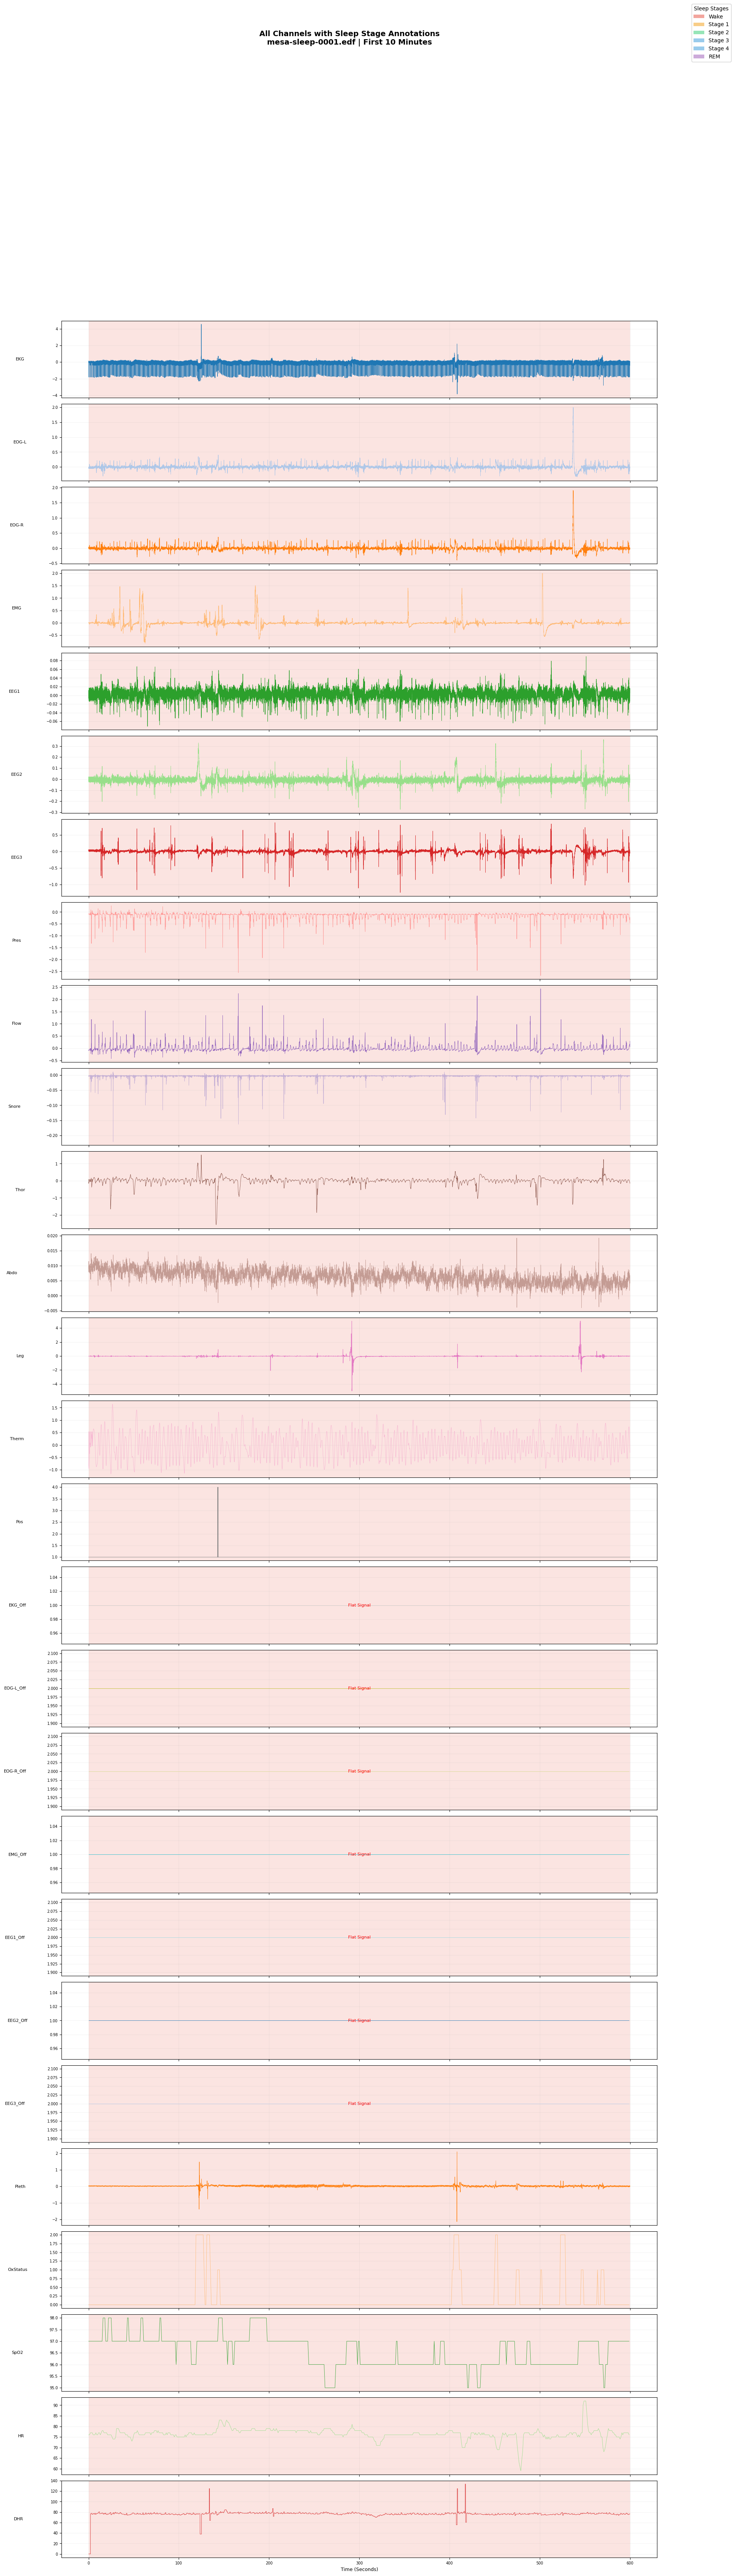

✅ Figure saved as: all_channels_annotated.png


In [21]:
# ================================================================
# Display All Channels with Sleep Stage Annotations
# ================================================================

import xml.etree.ElementTree as ET
from matplotlib.patches import Patch

# ======================================
# Load Annotation File
# ======================================

xml_files = sorted([
    f for f in os.listdir(ann_path)
    if f.endswith('.xml')
])

sample_xml = os.path.join(
    ann_path,
    xml_files[0]
)

print(f'📂 Annotations: {xml_files[0]}')

# ======================================
# Sleep Stage Colors
# ======================================

stage_colors = {

    'Wake': ('#e74c3c', 0),

    'Stage 1': ('#f39c12', 1),

    'Stage 2': ('#2ecc71', 2),

    'Stage 3': ('#3498db', 3),

    'Stage 4': ('#3498db', 3),

    'REM': ('#9b59b6', 4),
}

# ======================================
# Read Sleep Stage Events
# ======================================

events = []

tree = ET.parse(sample_xml)

root = tree.getroot()

for event in root.iter('ScoredEvent'):

    concept = event.find('EventConcept')

    start = event.find('Start')

    duration = event.find('Duration')

    # Skip invalid events
    if (
        concept is None
        or start is None
        or duration is None
    ):
        continue

    stage = concept.text

    # Match sleep stage
    for key in stage_colors:

        if key in stage:

            events.append({

                'stage': key,

                'start': float(start.text),

                'duration': float(duration.text),

                'color': stage_colors[key][0]
            })

            break

print(f'Number of annotations: {len(events)}')

# ======================================
# Plot All Channels
# ======================================

show_sec = 600   # First 10 minutes

# Create figure
fig = plt.figure(
    figsize=(20, n_channels * 2.8)
)

# Grid layout
gs = gridspec.GridSpec(
    n_channels,
    1,
    figure=fig,
    hspace=0.08
)

# ======================================
# Plot Each Channel
# ======================================

for i in range(n_channels):

    ax = fig.add_subplot(gs[i])

    sig = signals[i]

    fs = int(fs_list[i])

    # Number of displayed samples
    n = min(
        show_sec * fs,
        len(sig)
    )

    # Time axis
    t = np.arange(n) / fs

    # ======================================
    # Draw Sleep Stage Background
    # ======================================

    for ev in events:

        # Skip events outside range
        if ev['start'] > show_sec:
            continue

        end = min(
            ev['start'] + ev['duration'],
            show_sec
        )

        ax.axvspan(
            ev['start'],
            end,
            alpha=0.15,
            color=ev['color'],
            linewidth=0
        )

    # ======================================
    # Plot Signal
    # ======================================

    ax.plot(
        t,
        sig[:n],
        color=colors[i % len(colors)],
        linewidth=0.6
    )

    # Hide x-axis labels except last channel
    if i < n_channels - 1:

        ax.set_xticklabels([])

    else:

        ax.set_xlabel(
            'Time (Seconds)',
            fontsize=9
        )

    # Channel label
    ax.set_ylabel(
        ch_names[i].strip(),
        fontsize=8,
        rotation=0,
        labelpad=60,
        va='center'
    )

    # Tick size
    ax.tick_params(labelsize=7)

    # Add grid
    ax.grid(True, alpha=0.15)

    # Handle flat signals
    if sig[:n].std() < 1e-6:

        ax.text(
            0.5,
            0.5,
            'Flat Signal',
            transform=ax.transAxes,
            ha='center',
            va='center',
            color='red',
            fontsize=8
        )

# ======================================
# Sleep Stage Legend
# ======================================

legend_elements = [

    Patch(
        facecolor=v[0],
        alpha=0.5,
        label=k
    )

    for k, v in stage_colors.items()
]

fig.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=10,
    title='Sleep Stages',
    framealpha=0.9,
    bbox_to_anchor=(1.0, 0.99)
)

# ======================================
# Main Figure Title
# ======================================

fig.suptitle(
    f'All Channels with Sleep Stage Annotations\n'
    f'{files[0]} | First {show_sec // 60} Minutes',
    fontsize=14,
    fontweight='bold'
)

# Save figure
plt.savefig(
    'all_channels_annotated.png',
    dpi=150,
    bbox_inches='tight'
)

# Show figure
plt.show()

print('✅ Figure saved as: all_channels_annotated.png')

## 📊  Cell 1 — Display Raw EOG-R Signal


Reading: mesa-sleep-0001.edf
Sampling Rate: 256 Hz  |  Total Samples: 11,058,944  |  Duration: 720.0 min


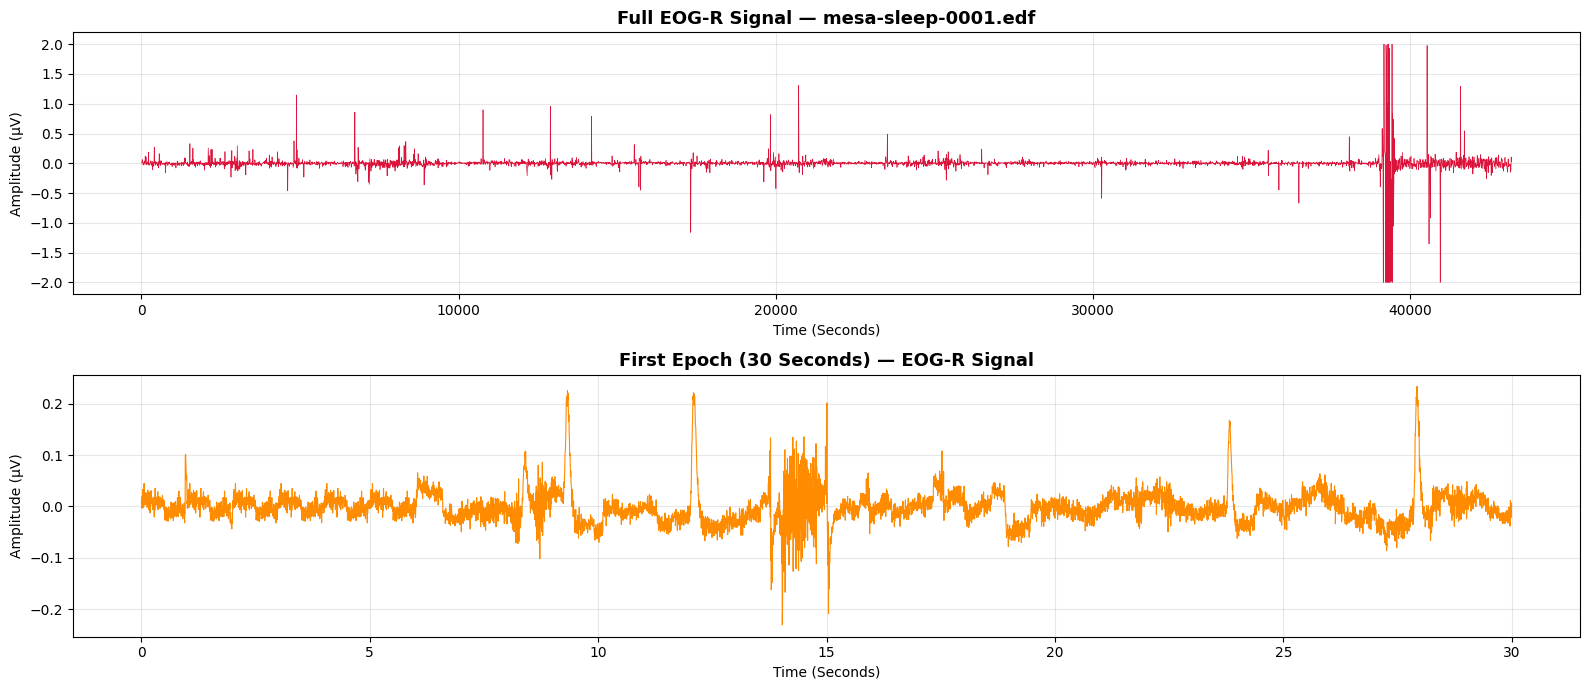

✅ Figure saved as: cell1_general_signal_r.png


In [22]:
# ========================================================
# Cell 1 — Display EOG-R Signal
# Read the first EDF file and display the EOG-R signal
# ========================================================

import pyedflib
import numpy as np
import matplotlib.pyplot as plt

# ======================================
# Load First EDF File
# ======================================

files = sorted([
    f for f in os.listdir(data_path)
    if f.endswith('.edf')
])

sample_file = os.path.join(
    data_path,
    files[0]
)

print(f'Reading: {files[0]}')

# ======================================
# Read Raw EOG-R Signal
# ======================================

with pyedflib.EdfReader(sample_file) as f:

    # Get channel names
    ch_names = f.getSignalLabels()

    # Get sampling frequencies
    fs_list = f.getSampleFrequencies()

    # Find EOG-R channel index
    eog_r_idx = next(
        (
            i for i, ch in enumerate(ch_names)
            if ch.strip() == 'EOG-R'
        ),
        None
    )

    # Check if channel exists
    if eog_r_idx is None:

        raise ValueError(
            "Channel EOG-R not found!"
        )

    # Read raw signal
    raw_signal = f.readSignal(
        eog_r_idx
    ).astype(np.float32)

    # Sampling frequency
    fs = int(fs_list[eog_r_idx])

# ======================================
# Signal Information
# ======================================

print(
    f'Sampling Rate: {fs} Hz  |  '
    f'Total Samples: {len(raw_signal):,}  |  '
    f'Duration: {len(raw_signal) / fs / 60:.1f} min'
)

# ======================================
# Time Axis
# ======================================

t = np.arange(len(raw_signal)) / fs

# Show first 30 seconds
show_sec = 30

n_show = show_sec * fs

# ======================================
# Create Figure
# ======================================

fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 7)
)

# ======================================
# Plot 1 — Full Signal
# ======================================

# Downsample for faster display
step = max(
    1,
    len(raw_signal) // 5000
)

axes[0].plot(
    t[::step],
    raw_signal[::step],
    color='crimson',
    linewidth=0.5
)

axes[0].set_title(
    f'Full EOG-R Signal — {files[0]}',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel('Time (Seconds)')

axes[0].set_ylabel('Amplitude (µV)')

axes[0].grid(True, alpha=0.3)

# ======================================
# Plot 2 — First 30 Seconds
# ======================================

axes[1].plot(
    t[:n_show],
    raw_signal[:n_show],
    color='darkorange',
    linewidth=0.8
)

axes[1].set_title(
    'First Epoch (30 Seconds) — EOG-R Signal',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_xlabel('Time (Seconds)')

axes[1].set_ylabel('Amplitude (µV)')

axes[1].grid(True, alpha=0.3)

# ======================================
# Final Layout
# ======================================

plt.tight_layout()

# Save figure
plt.savefig(
    'cell1_general_signal_r.png',
    dpi=150,
    bbox_inches='tight'
)

# Show figure
plt.show()

print(
    '✅ Figure saved as: '
    'cell1_general_signal_r.png'
)

## 📊 Cell 2 — Display EOG-L and EOG-R Signals Separately

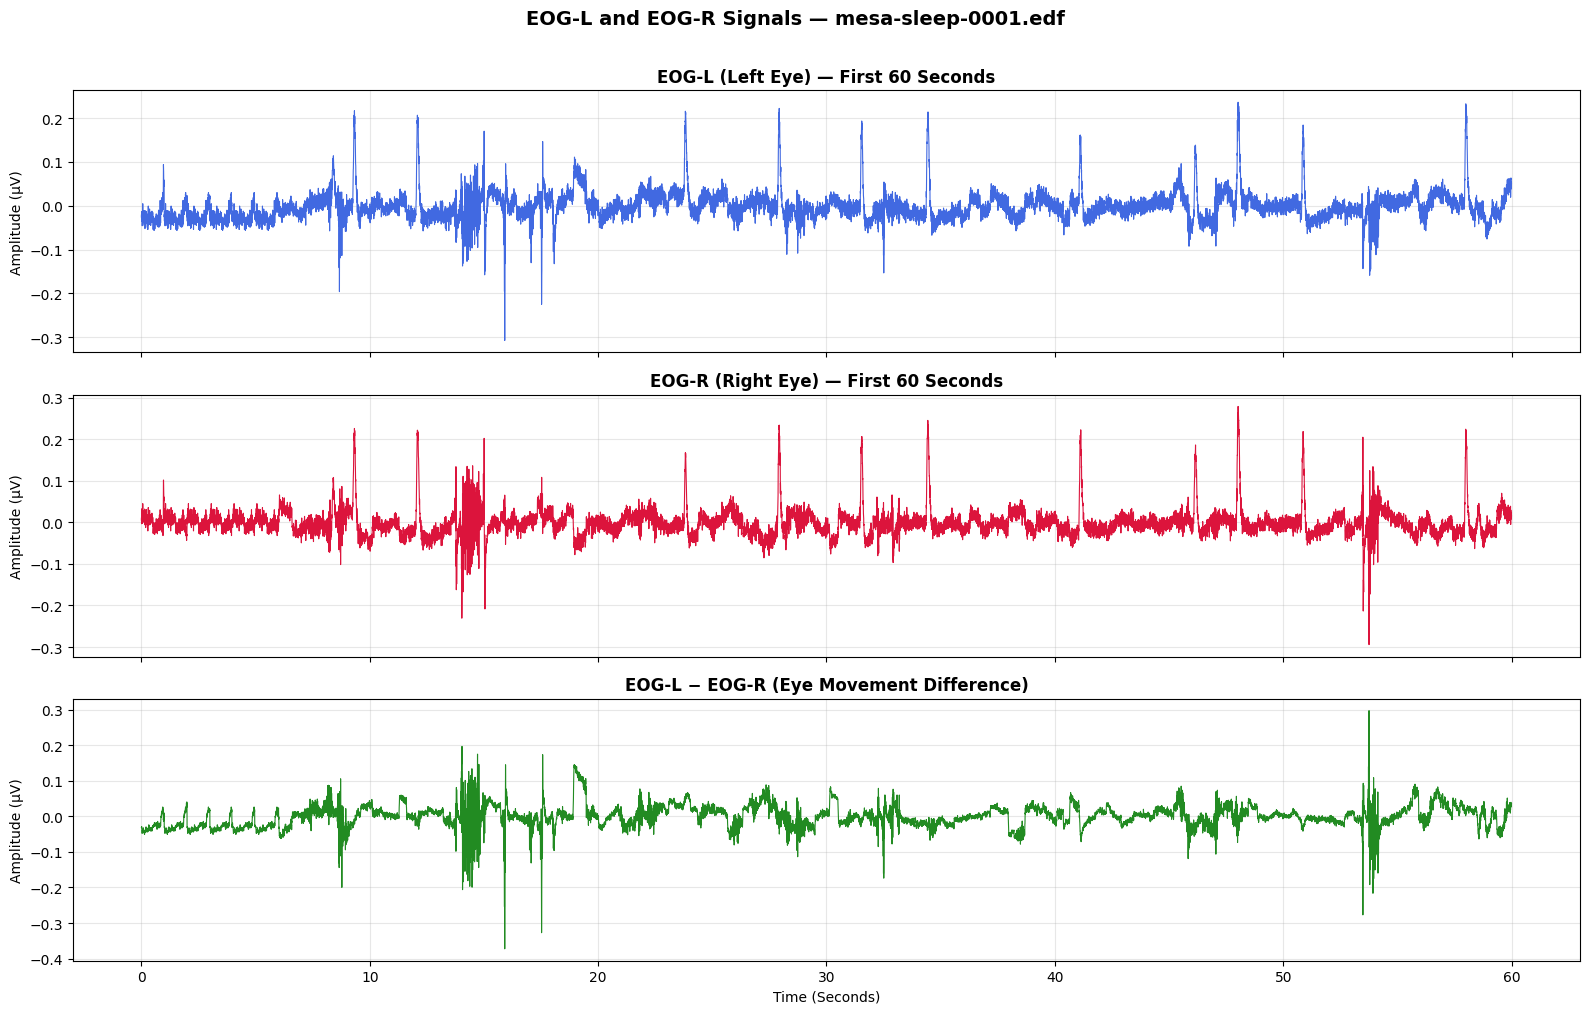

✅ Figure saved as: cell2_eog_lr.png


In [23]:
# ========================================================
# Cell 2 — Display EOG-L and EOG-R Signals
# Compare left and right eye movement signals
# ========================================================

with pyedflib.EdfReader(sample_file) as f:

    # Get channel names
    ch_names = f.getSignalLabels()

    # Get sampling frequencies
    fs_list = f.getSampleFrequencies()

    # Find EOG-L channel index
    eog_l_idx = next(
        (
            i for i, ch in enumerate(ch_names)
            if ch.strip() == 'EOG-L'
        ),
        None
    )

    # Find EOG-R channel index
    eog_r_idx = next(
        (
            i for i, ch in enumerate(ch_names)
            if ch.strip() == 'EOG-R'
        ),
        None
    )

    # Check if channels exist
    if eog_l_idx is None or eog_r_idx is None:

        raise ValueError(
            '❌ EOG-L or EOG-R channel not found!'
        )

    # Read raw EOG-L signal
    eog_l_raw = f.readSignal(
        eog_l_idx
    ).astype(np.float32)

    # Read raw EOG-R signal
    eog_r_raw = f.readSignal(
        eog_r_idx
    ).astype(np.float32)

    # Sampling frequency
    fs = int(fs_list[eog_l_idx])

# ======================================
# Time Axis
# ======================================

t = np.arange(len(eog_l_raw)) / fs

# Show first 60 seconds
show_sec = 60

n_show = show_sec * fs

# ======================================
# Create Figure
# ======================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(16, 10),
    sharex=True
)

# ======================================
# Plot EOG-L Signal
# ======================================

axes[0].plot(
    t[:n_show],
    eog_l_raw[:n_show],
    color='royalblue',
    linewidth=0.8
)

axes[0].set_title(
    'EOG-L (Left Eye) — First 60 Seconds',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_ylabel(
    'Amplitude (µV)'
)

axes[0].grid(True, alpha=0.3)

# ======================================
# Plot EOG-R Signal
# ======================================

axes[1].plot(
    t[:n_show],
    eog_r_raw[:n_show],
    color='crimson',
    linewidth=0.8
)

axes[1].set_title(
    'EOG-R (Right Eye) — First 60 Seconds',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_ylabel(
    'Amplitude (µV)'
)

axes[1].grid(True, alpha=0.3)

# ======================================
# Plot Difference Signal
# ======================================

# Difference between left and right eye
diff = eog_l_raw[:n_show] - eog_r_raw[:n_show]

axes[2].plot(
    t[:n_show],
    diff,
    color='forestgreen',
    linewidth=0.8
)

axes[2].set_title(
    'EOG-L − EOG-R (Eye Movement Difference)',
    fontsize=12,
    fontweight='bold'
)

axes[2].set_xlabel(
    'Time (Seconds)'
)

axes[2].set_ylabel(
    'Amplitude (µV)'
)

axes[2].grid(True, alpha=0.3)

# ======================================
# Main Figure Title
# ======================================

plt.suptitle(
    f'EOG-L and EOG-R Signals — {files[0]}',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(
    'cell2_eog_lr.png',
    dpi=150,
    bbox_inches='tight'
)

# Show figure
plt.show()

print(
    '✅ Figure saved as: cell2_eog_lr.png'
)

## 📊 Cell 3 — Compare EOG-R Signal Before and After Preprocessing


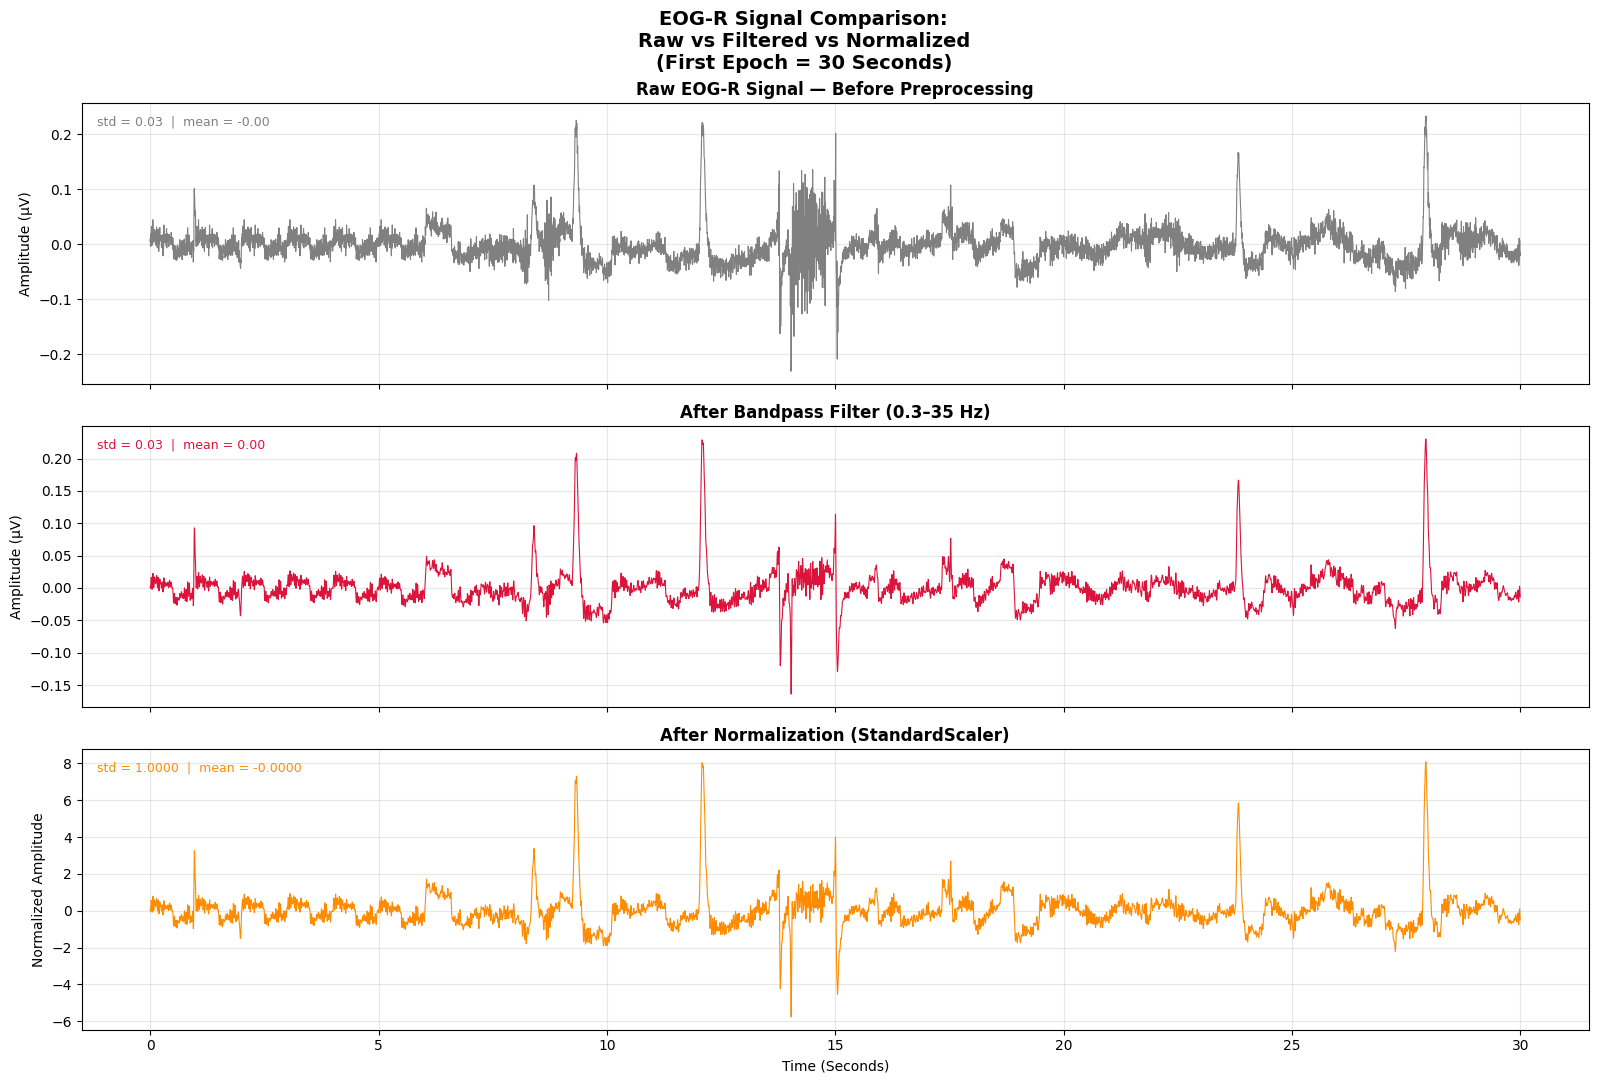

✅ Figure saved as: cell3_filter_comparison_r.png


In [24]:
# ========================================================
# Cell 3 — Compare EOG-R Signal Before and After
# Bandpass Filtering and Normalization
# ========================================================

from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler

# ======================================
# Read Raw EOG-R Signal
# ======================================

with pyedflib.EdfReader(sample_file) as f:

    # Get channel names
    ch_names = f.getSignalLabels()

    # Get sampling frequencies
    fs_list = f.getSampleFrequencies()

    # Find EOG-R channel index
    eog_r_idx = next(
        (
            i for i, ch in enumerate(ch_names)
            if ch.strip() == 'EOG-R'
        ),
        None
    )

    # Check if channel exists
    if eog_r_idx is None:

        raise ValueError(
            "Channel EOG-R not found!"
        )

    # Read raw signal
    sig_raw = f.readSignal(
        eog_r_idx
    ).astype(np.float32)

    # Sampling frequency
    fs = int(fs_list[eog_r_idx])

# ======================================
# Apply Bandpass Filter
# ======================================

# Nyquist frequency
nyquist = 0.5 * fs

# Create Butterworth filter
b, a = butter(
    4,
    [0.3 / nyquist, 35.0 / nyquist],
    btype='band'
)

# Apply filter
sig_filtered = filtfilt(
    b,
    a,
    sig_raw
).astype(np.float32)

# ======================================
# Apply Normalization
# ======================================

# First epoch = 30 seconds
epoch_len = 30 * fs

# Raw epoch
epoch_raw = sig_raw[:epoch_len]

# Filtered epoch
epoch_filt = sig_filtered[:epoch_len]

# Standard normalization
scaler = StandardScaler()

epoch_norm = scaler.fit_transform(
    epoch_filt.reshape(-1, 1)
).flatten()

# Time axis
t_epoch = np.arange(epoch_len) / fs

# ======================================
# Create Figure
# ======================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(16, 11),
    sharex=True
)

# ======================================
# Plot 1 — Raw Signal
# ======================================

axes[0].plot(
    t_epoch,
    epoch_raw,
    color='gray',
    linewidth=0.8
)

axes[0].set_title(
    'Raw EOG-R Signal — Before Preprocessing',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_ylabel(
    'Amplitude (µV)'
)

axes[0].grid(True, alpha=0.3)

# Signal statistics
axes[0].annotate(
    f'std = {epoch_raw.std():.2f}  |  '
    f'mean = {epoch_raw.mean():.2f}',
    xy=(0.01, 0.92),
    xycoords='axes fraction',
    fontsize=9,
    color='gray'
)

# ======================================
# Plot 2 — Filtered Signal
# ======================================

axes[1].plot(
    t_epoch,
    epoch_filt,
    color='crimson',
    linewidth=0.8
)

axes[1].set_title(
    'After Bandpass Filter (0.3–35 Hz)',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_ylabel(
    'Amplitude (µV)'
)

axes[1].grid(True, alpha=0.3)

# Signal statistics
axes[1].annotate(
    f'std = {epoch_filt.std():.2f}  |  '
    f'mean = {epoch_filt.mean():.2f}',
    xy=(0.01, 0.92),
    xycoords='axes fraction',
    fontsize=9,
    color='crimson'
)

# ======================================
# Plot 3 — Normalized Signal
# ======================================

axes[2].plot(
    t_epoch,
    epoch_norm,
    color='darkorange',
    linewidth=0.8
)

axes[2].set_title(
    'After Normalization (StandardScaler)',
    fontsize=12,
    fontweight='bold'
)

axes[2].set_xlabel(
    'Time (Seconds)'
)

axes[2].set_ylabel(
    'Normalized Amplitude'
)

axes[2].grid(True, alpha=0.3)

# Signal statistics
axes[2].annotate(
    f'std = {epoch_norm.std():.4f}  |  '
    f'mean = {epoch_norm.mean():.4f}',
    xy=(0.01, 0.92),
    xycoords='axes fraction',
    fontsize=9,
    color='darkorange'
)

# ======================================
# Main Figure Title
# ======================================

plt.suptitle(
    'EOG-R Signal Comparison:\n'
    'Raw vs Filtered vs Normalized\n'
    '(First Epoch = 30 Seconds)',
    fontsize=14,
    fontweight='bold'
)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(
    'cell3_filter_comparison_r.png',
    dpi=150,
    bbox_inches='tight'
)

# Show figure
plt.show()

print(
    '✅ Figure saved as: '
    'cell3_filter_comparison_r.png'
)

In [25]:
import gc
# Step 1:Download all subjects
subjects = load_all_subjects(data_path, ann_path, seq_len=SEQ_LEN)
print(f'\nTotal subjects loaded: {len(subjects)}')
gc.collect()

Loaded: mesa-sleep-0001.edf — 1439 epochs → 1429 sequences
Loaded: mesa-sleep-0002.edf — 1319 epochs → 1309 sequences
Loaded: mesa-sleep-0006.edf — 1079 epochs → 1069 sequences
Loaded: mesa-sleep-0010.edf — 1199 epochs → 1189 sequences
Loaded: mesa-sleep-0012.edf — 1427 epochs → 1417 sequences
Loaded: mesa-sleep-0014.edf — 1679 epochs → 1669 sequences
Loaded: mesa-sleep-0016.edf — 1199 epochs → 1189 sequences
Loaded: mesa-sleep-0021.edf — 1079 epochs → 1069 sequences
Loaded: mesa-sleep-0027.edf — 1199 epochs → 1189 sequences
Loaded: mesa-sleep-0028.edf — 1139 epochs → 1129 sequences

Total subjects loaded: 10


18100

In [25]:
print("Number of subjects loaded:", len(subjects))
for i, (X, y) in enumerate(subjects):
    print(f"  Subject {i+1}: {len(X)} sequences")

Number of subjects loaded: 10
  Subject 1: 1429 sequences
  Subject 2: 1309 sequences
  Subject 3: 1069 sequences
  Subject 4: 1189 sequences
  Subject 5: 1417 sequences
  Subject 6: 1669 sequences
  Subject 7: 1189 sequences
  Subject 8: 1069 sequences
  Subject 9: 1189 sequences
  Subject 10: 1129 sequences


In [26]:
files = sorted([f for f in os.listdir(data_path) if f.endswith('.edf')])
print("EDF files found:", len(files))
for file in files:
    xml = file.replace('.edf', '-nsrr.xml')
    xml_path = os.path.join(ann_path, xml)
    print(f"  {file} → annotation exists: {os.path.exists(xml_path)}")
    print(f"    looking for: {xml_path}")

EDF files found: 10
  mesa-sleep-0001.edf → annotation exists: True
    looking for: C:\Users\Laptop\Desktop\Project\Annotations\mesa-sleep-0001-nsrr.xml
  mesa-sleep-0002.edf → annotation exists: True
    looking for: C:\Users\Laptop\Desktop\Project\Annotations\mesa-sleep-0002-nsrr.xml
  mesa-sleep-0006.edf → annotation exists: True
    looking for: C:\Users\Laptop\Desktop\Project\Annotations\mesa-sleep-0006-nsrr.xml
  mesa-sleep-0010.edf → annotation exists: True
    looking for: C:\Users\Laptop\Desktop\Project\Annotations\mesa-sleep-0010-nsrr.xml
  mesa-sleep-0012.edf → annotation exists: True
    looking for: C:\Users\Laptop\Desktop\Project\Annotations\mesa-sleep-0012-nsrr.xml
  mesa-sleep-0014.edf → annotation exists: True
    looking for: C:\Users\Laptop\Desktop\Project\Annotations\mesa-sleep-0014-nsrr.xml
  mesa-sleep-0016.edf → annotation exists: True
    looking for: C:\Users\Laptop\Desktop\Project\Annotations\mesa-sleep-0016-nsrr.xml
  mesa-sleep-0021.edf → annotation exists:

In [27]:
files = sorted([f for f in os.listdir(data_path) if f.endswith('.edf')])

for file in files:
    edf_path = os.path.join(data_path, file)
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        print(f"✅ {file} — channels: {raw.ch_names}")
    except Exception as e:
        print(f"❌ {file} — ERROR: {e}")

✅ mesa-sleep-0001.edf — channels: ['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG_Off', 'EOG-L_Off', 'EOG-R_Off', 'EMG_Off', 'EEG1_Off', 'EEG2_Off', 'EEG3_Off', 'Pleth', 'OxStatus', 'SpO2', 'HR', 'DHR']
✅ mesa-sleep-0002.edf — channels: ['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG_Off', 'EOG-L_Off', 'EOG-R_Off', 'EMG_Off', 'EEG1_Off', 'EEG2_Off', 'EEG3_Off', 'Pleth', 'OxStatus', 'SpO2', 'HR', 'DHR']
✅ mesa-sleep-0006.edf — channels: ['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG_Off', 'EOG-L_Off', 'EOG-R_Off', 'EMG_Off', 'EEG1_Off', 'EEG2_Off', 'EEG3_Off', 'Pleth', 'OxStatus', 'SpO2', 'HR', 'DHR']
✅ mesa-sleep-0010.edf — channels: ['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'E

In [ ]:
# Step 2: Split at the subject level (80% Train / 10% Val / 10% Test)
X_train, X_val, X_test, y_train, y_val, y_test = split_subjects(subjects)

print("\nClass distribution in Train:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Class distribution in Val  :", dict(zip(*np.unique(y_val,   return_counts=True))))
print("Class distribution in Test :", dict(zip(*np.unique(y_test,  return_counts=True))))


Train: 8 subjects → 10340 sequences  (80%)
Val  : 1   subjects → 1189 sequences  (10%)
Test : 1  subjects → 1129 sequences  (10%)

Class distribution in Train: {np.int64(0): np.int64(4816), np.int64(1): np.int64(734), np.int64(2): np.int64(3094), np.int64(3): np.int64(773), np.int64(4): np.int64(923)}
Class distribution in Val  : {np.int64(0): np.int64(205), np.int64(1): np.int64(130), np.int64(2): np.int64(641), np.int64(3): np.int64(24), np.int64(4): np.int64(189)}
Class distribution in Test : {np.int64(0): np.int64(475), np.int64(1): np.int64(70), np.int64(2): np.int64(373), np.int64(3): np.int64(62), np.int64(4): np.int64(149)}


In [29]:
# Step 3: Class weights
classes    = np.unique(y_train)
weights_np = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
weights    = torch.tensor(weights_np, dtype=torch.float32)
print('Class weights:', dict(zip(classes, weights_np.round(3))))


Class weights: {np.int64(0): np.float64(0.429), np.int64(1): np.float64(2.817), np.int64(2): np.float64(0.668), np.int64(3): np.float64(2.675), np.int64(4): np.float64(2.241)}


## 📊 Class Distribution — Is the data balanced?


C:\Users\Laptop\AppData\Local\Temp\ipykernel_10528\2939124034.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Laptop\AppData\Local\Temp\ipykernel_10528\2939124034.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
C:\ProgramData\anaconda3\envs\torch_gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


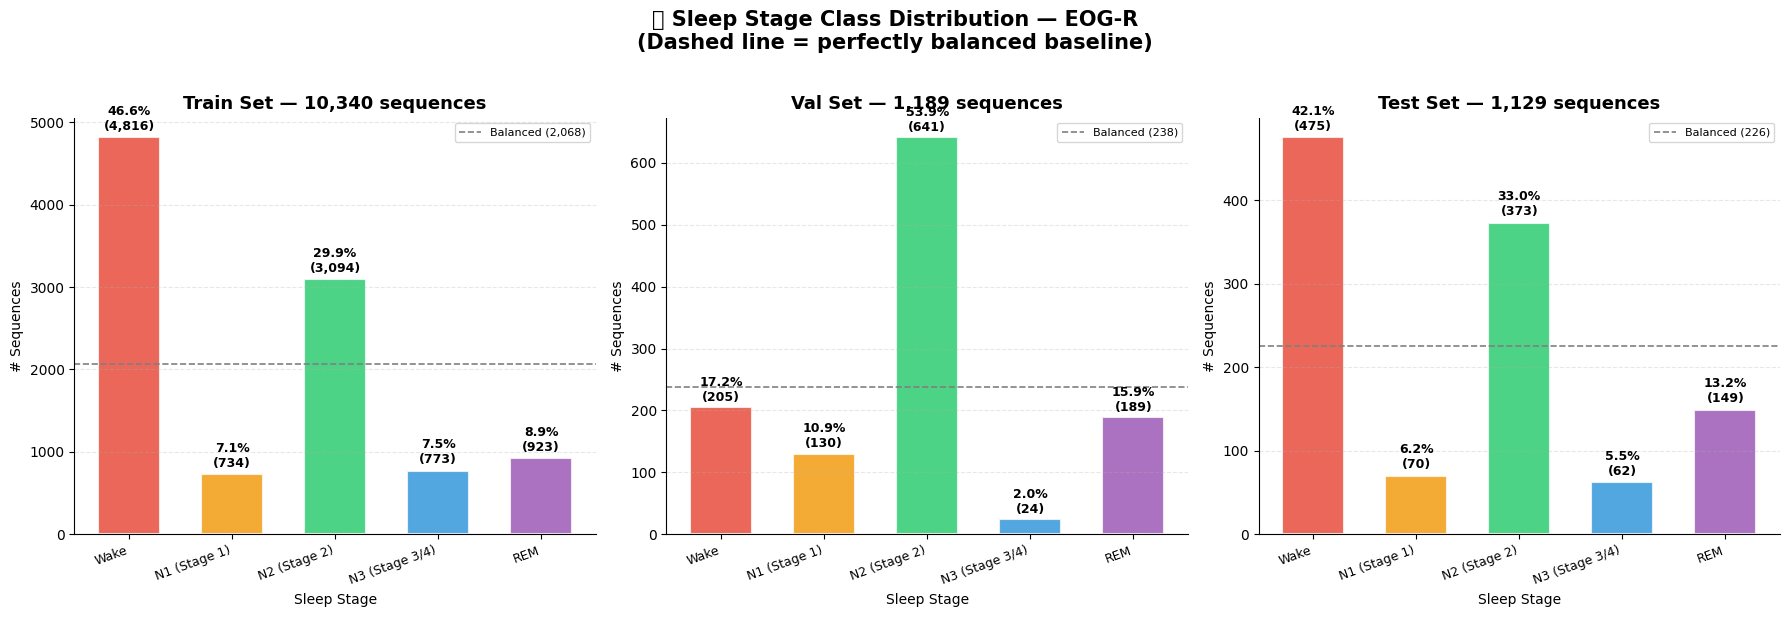


📊 Imbalance Analysis (Train set):
  Wake              :  4,816  ( 46.6%)  ████████████████████
  N1 (Stage 1)      :    734  (  7.1%)  ███
  N2 (Stage 2)      :  3,094  ( 29.9%)  ████████████
  N3 (Stage 3/4)    :    773  (  7.5%)  ███
  REM               :    923  (  8.9%)  ███

  Imbalance ratio (max/min): 6.6x
  → Data is NOT balanced - class weights are required


In [ ]:
# ================================================================
# Bar Plot — Sleep Stage Class Distribution
# Show class balance in:
# - Train set
# - Validation set
# - Test set
# ================================================================

# ======================================
# Sleep Stage Information
# ======================================

stage_names = [
    "Wake",
    "N1 (Stage 1)",
    "N2 (Stage 2)",
    "N3 (Stage 3/4)",
    "REM"
]

stage_colors = [
    "#E74C3C",
    "#F39C12",
    "#2ECC71",
    "#3498DB",
    "#9B59B6"
]

# ======================================
# Count Samples per Class
# ======================================

def count_classes(
    y,
    n_classes=5
):

    counts = np.bincount(
        y,
        minlength=n_classes
    )

    return counts

# Count classes for each dataset
train_counts = count_classes(y_train)

val_counts = count_classes(y_val)

test_counts = count_classes(y_test)

# ======================================
# Create Figure
# ======================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    sharey=False
)

# Dataset information
splits = [

    ("Train", train_counts, y_train),

    ("Val", val_counts, y_val),

    ("Test", test_counts, y_test)
]

# ======================================
# Plot Each Dataset
# ======================================

for ax, (split_name, counts, y_arr) in zip(axes, splits):

    # Total number of sequences
    total = counts.sum()

    # Percentages
    pcts = counts / total * 100

    # Create bar plot
    bars = ax.bar(
        stage_names,
        counts,
        color=stage_colors,
        alpha=0.85,
        edgecolor="white",
        linewidth=1.5,
        width=0.6
    )

    # ======================================
    # Add Percentage Labels
    # ======================================

    for bar, pct, cnt in zip(
        bars,
        pcts,
        counts
    ):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.005,
            f"{pct:.1f}%\n({cnt:,})",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

    # ======================================
    # Axis Settings
    # ======================================

    ax.set_title(
        f"{split_name} Set — {total:,} sequences",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Sleep Stage",
        fontsize=10
    )

    ax.set_ylabel(
        "# Sequences",
        fontsize=10
    )

    ax.set_xticks(range(5))

    ax.set_xticklabels(
        stage_names,
        rotation=20,
        ha="right",
        fontsize=9
    )

    # Add grid
    ax.grid(
        axis="y",
        alpha=0.3,
        linestyle="--"
    )

    # Remove top/right borders
    ax.spines[
        ["top", "right"]
    ].set_visible(False)

    # ======================================
    # Balanced Reference Line
    # ======================================

    balanced_line = total / 5

    ax.axhline(
        balanced_line,
        color="gray",
        linestyle="--",
        linewidth=1.2,
        label=f"Balanced ({balanced_line:,.0f})"
    )

    ax.legend(fontsize=8)

# ======================================
# Main Figure Title
# ======================================

plt.suptitle(
    "📊 Sleep Stage Class Distribution — EOG-R\n"
    "(Dashed Line = Perfectly Balanced Dataset)",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(
    "class_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

# Show figure
plt.show()

# ======================================
# Imbalance Analysis
# ======================================

print("\n📊 Imbalance Analysis (Train Set):")

for name, cnt in zip(stage_names, train_counts):

    ratio = cnt / train_counts.max()

    bar = "█" * int(ratio * 20)

    print(
        f"  {name:<18}: "
        f"{cnt:>6,}  "
        f"({cnt / train_counts.sum() * 100:5.1f}%)  "
        f"{bar}"
    )

# Imbalance ratio
imbalance_ratio = (
    train_counts.max() /
    train_counts.min()
)

print(
    f"\n  Imbalance ratio (max/min): "
    f"{imbalance_ratio:.1f}x"
)

# Final conclusion
print(
    "  → Data is "
    f"{'NOT balanced - class weights are required' if imbalance_ratio > 2 else 'approximately balanced ✅'}"
)

In [ ]:
# ================================================================
# Step 4 — Create Datasets and DataLoaders
# Use WeightedRandomSampler to handle class imbalance
# ================================================================

from torch.utils.data import WeightedRandomSampler

# ======================================
# Create PyTorch Datasets
# ======================================

train_dataset = SleepDataset(
    X_train,
    y_train
)

val_dataset = SleepDataset(
    X_val,
    y_val
)

test_dataset = SleepDataset(
    X_test,
    y_test
)

# ======================================
# Create Sample Weights
# Each sample gets a weight based on:
# - Its class frequency
# - Class imbalance
# ======================================

sample_weights = torch.tensor(

    [weights_np[label] for label in y_train],

    dtype=torch.float32
)

# ======================================
# Weighted Random Sampler
# Oversamples minority classes
# ======================================

sampler = WeightedRandomSampler(

    weights=sample_weights,

    num_samples=len(sample_weights),

    replacement=True
)

# ======================================
# Create DataLoaders
# batch_size reduced from 32 → 16
# to reduce memory usage
# ======================================

train_loader = DataLoader(

    train_dataset,

    batch_size=16,

    sampler=sampler,

    num_workers=0
)

val_loader = DataLoader(

    val_dataset,

    batch_size=16,

    shuffle=False,

    num_workers=0
)

test_loader = DataLoader(

    test_dataset,

    batch_size=16,

    shuffle=False,

    num_workers=0
)

# ======================================
# Display Information
# ======================================

print(
    'Train batches:',
    len(train_loader)
)

print(
    'Input shape sample:',
    next(iter(train_loader))[0].shape
)

print(
    '✅ WeightedRandomSampler active — '
    'class imbalance handled'
)

Train batches: 647
Input shape sample: torch.Size([16, 10, 7680])
✅ WeightedRandomSampler active — class imbalance handled


In [ ]:
# ================================================================
# Step 5 — Initialize Sleep Staging Model
# Lightweight ResNet1D + Bi-LSTM + Attention
# ================================================================

# ======================================
# Create Model
# ======================================

model = SleepModel(

    # Feature dimension from ResNet encoder
    resnet_out=128,

    # Reduced LSTM hidden size
    # 256 → 128 to reduce memory usage
    lstm_hidden=128,

    # Number of LSTM layers
    lstm_layers=2,

    # Number of sleep stage classes
    num_classes=5,

    # Dropout rate
    dropout=0.3
)

# ======================================
# Display Model Architecture
# ======================================

print(model)

# ======================================
# Count Trainable Parameters
# ======================================

total_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)

print(
    f"\nTotal trainable parameters: "
    f"{total_params:,}"
)

# ======================================
# Training Features
# ======================================

print(
    "✅ Mixed Precision Training (AMP) "
    "will be used if GPU is available"
)

print(
    "✅ WeightedRandomSampler active "
    "for handling class imbalance"
)

SleepModel(
  (encoder): ResNet1DEncoder(
    (stem): Sequential(
      (0): Conv1d(1, 32, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (layer1): Sequential(
      (0): ResidualBlock1D(
        (conv1): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
        (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
        (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (drop): Dropout(p=0.3, inplace=False)
        (relu): ReLU(inplace=True)
        (shortcut): Sequential(
          (0): Conv1d(32, 64, kernel_size=(1,), stride=(1,), bias=False)
          (1): BatchNorm1d(64, 

In [33]:
# Step 6: Train
train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, weights=weights, epochs=30
)


Using: cuda


C:\Users\Laptop\AppData\Local\Temp\ipykernel_10528\3033930066.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)
Epoch 1/30:   0%|          | 0/647 [00:00<?, ?it/s]C:\Users\Laptop\AppData\Local\Temp\ipykernel_10528\3033930066.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/30: 100%|██████████| 647/647 [06:41<00:00,  1.61it/s]
C:\Users\Laptop\AppData\Local\Temp\ipykernel_10528\3033930066.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1: Train Loss=1.6704 Acc=0.3742 | Val Loss=2.9457 Acc=0.0917 F1=0.1361 | LR=9.97e-04
  ✅ Saved best model (F1=0.1361)


Epoch 2/30:   0%|          | 0/647 [00:00<?, ?it/s]C:\Users\Laptop\AppData\Local\Temp\ipykernel_10528\3033930066.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 2/30: 100%|██████████| 647/647 [05:45<00:00,  1.87it/s]
C:\Users\Laptop\AppData\Local\Temp\ipykernel_10528\3033930066.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 2: Train Loss=1.1344 Acc=0.5103 | Val Loss=1.0291 Acc=0.2624 F1=0.2749 | LR=9.89e-04
  ✅ Saved best model (F1=0.2749)


...

Epoch 28: Train Loss=0.2513 Acc=0.7936 | Val Loss=1.4924 Acc=0.4483 F1=0.4577 | LR=1.19e-05


Epoch 29/30:   0%|          | 0/647 [00:00<?, ?it/s]C:\Users\Laptop\AppData\Local\Temp\ipykernel_10528\3033930066.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 29/30: 100%|██████████| 647/647 [05:45<00:00,  1.87it/s]
C:\Users\Laptop\AppData\Local\Temp\ipykernel_10528\3033930066.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 29: Train Loss=0.2424 Acc=0.7942 | Val Loss=1.2380 Acc=0.4138 F1=0.4479 | LR=3.74e-06


Epoch 30/30:   0%|          | 0/647 [00:00<?, ?it/s]C:\Users\Laptop\AppData\Local\Temp\ipykernel_10528\3033930066.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 30/30: 100%|██████████| 647/647 [05:46<00:00,  1.87it/s]
C:\Users\Laptop\AppData\Local\Temp\ipykernel_10528\3033930066.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 30: Train Loss=0.2295 Acc=0.7995 | Val Loss=1.4426 Acc=0.4483 F1=0.4572 | LR=1.00e-06


In [34]:
# Step 7: Evaluate
preds, labels = evaluate(model, test_loader)


C:\Users\Laptop\AppData\Local\Temp\ipykernel_10528\525474071.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best.pth', map_location=de

              precision    recall  f1-score   support

        Wake       1.00      0.68      0.81       475
     Stage 1       0.15      0.49      0.23        70
     Stage 2       0.89      0.61      0.72       373
   Stage 3/4       0.47      1.00      0.64        62
         REM       0.54      0.70      0.61       149

    accuracy                           0.67      1129
   macro avg       0.61      0.70      0.60      1129
weighted avg       0.82      0.67      0.71      1129

Macro F1  : 0.604
Cohen Kappa: 0.5624


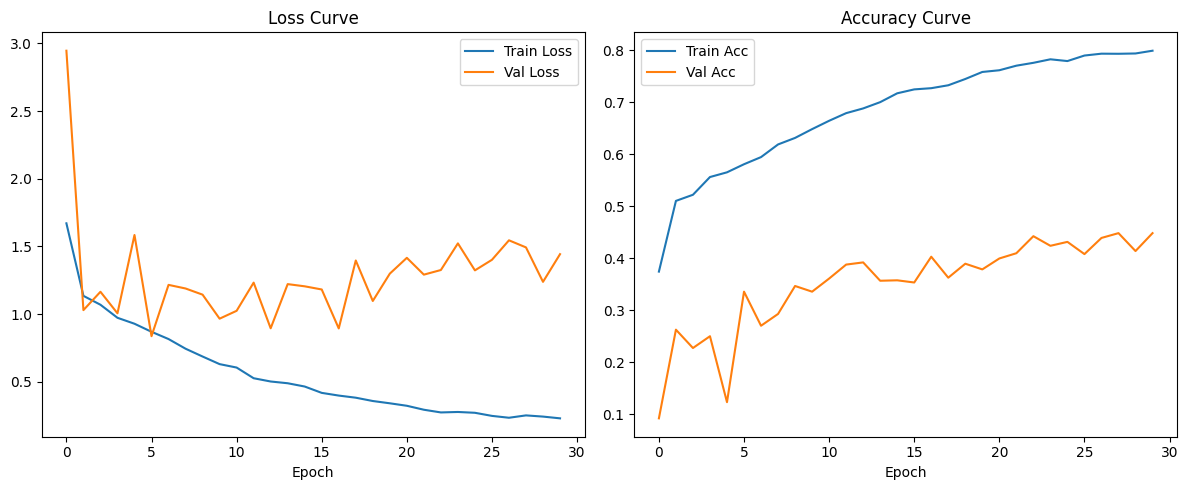

In [35]:
# Step 8: Plot training curves
plot_results(train_losses, val_losses, train_accs, val_accs)


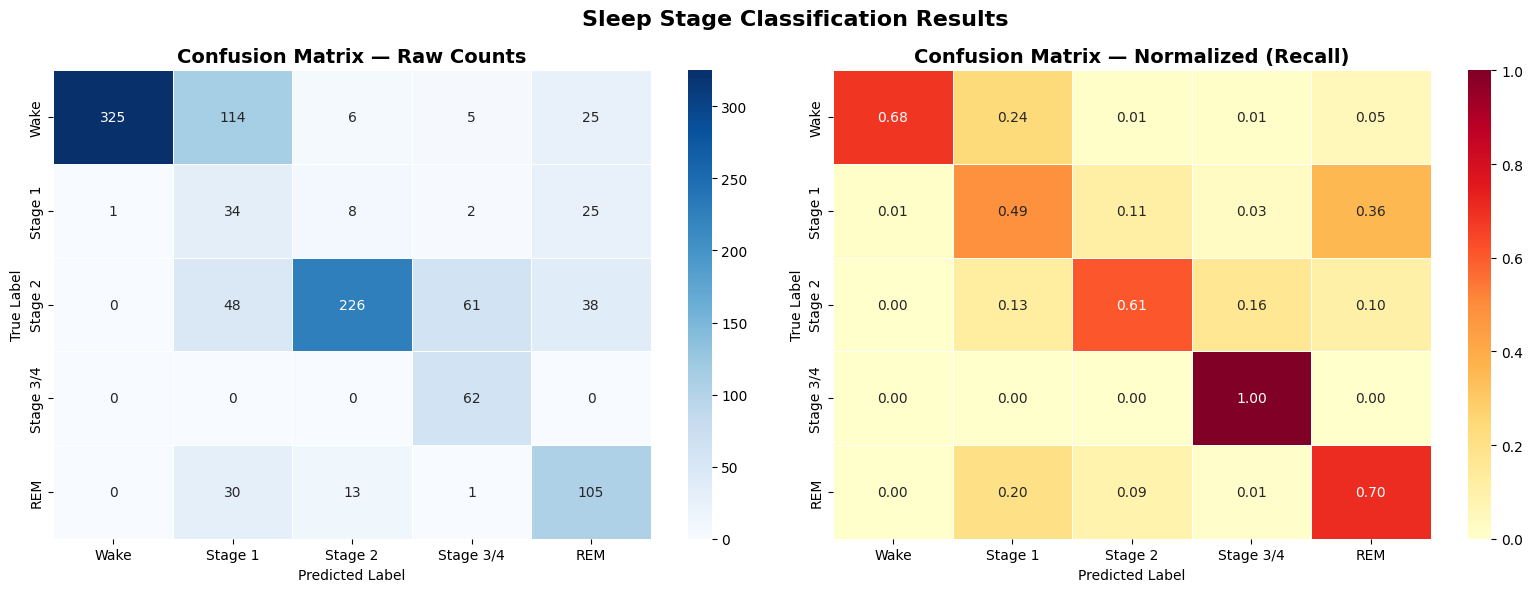

In [36]:
# Step 9: Confusion matrix
plot_confusion_matrix(labels, preds)


✅ تم الحفظ في: hypnogram.png


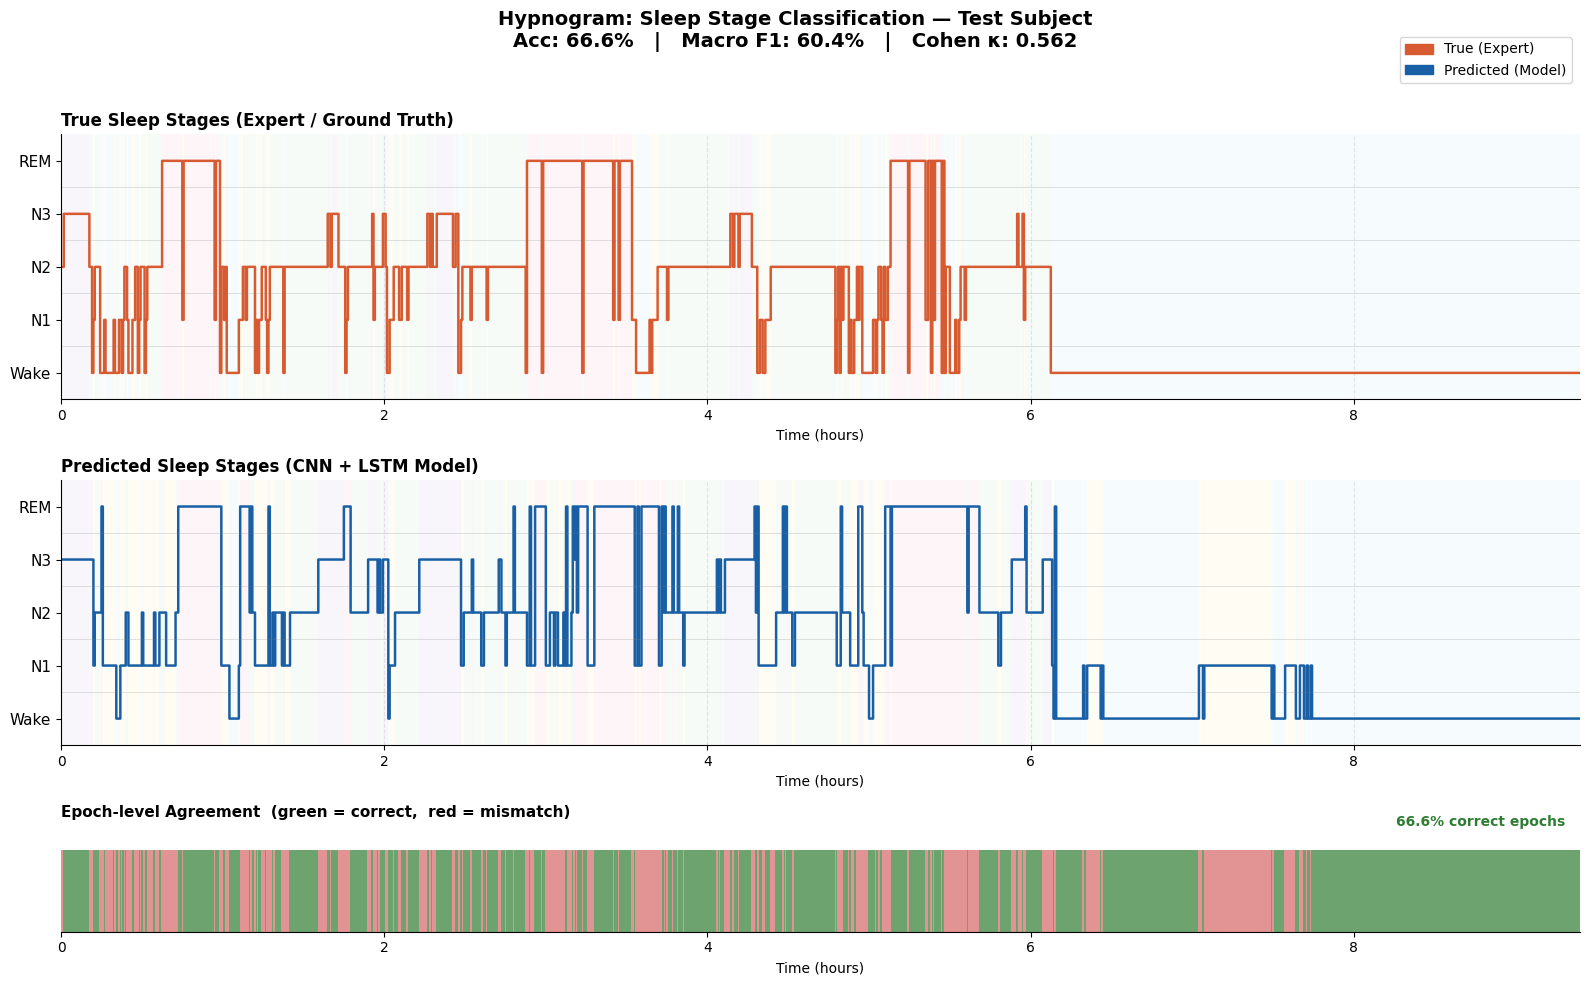

In [ ]:
# ============================================================
# Cell — Hypnogram (Predicted vs True)
# Compare:
# - True sleep stages (Expert labels)
# - Predicted sleep stages (Model output)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score
)

# ============================================================
# Hypnogram Function
# ============================================================

def plot_hypnogram(
    preds,
    labels,
    subject_id=None,
    save_path=None
):
    """
    Plot hypnogram comparison between:
    - Ground truth labels
    - Model predictions

    Parameters
    ----------
    preds : array-like
        Model predictions

    labels : array-like
        Ground truth labels

    subject_id : str
        Subject name or ID

    save_path : str
        Figure save path
    """

    # Convert to NumPy arrays
    preds = np.array(preds)

    labels = np.array(labels)

    # ======================================
    # Sleep Stage Information
    # ======================================

    stage_names = [
        'Wake',
        'N1',
        'N2',
        'N3',
        'REM'
    ]

    # Number of epochs
    n_epochs = len(labels)

    # Convert epochs to hours
    # Each epoch = 30 seconds
    time_hours = (
        np.arange(n_epochs) * 30 / 3600
    )

    # ======================================
    # Evaluation Metrics
    # ======================================

    acc = accuracy_score(
        labels,
        preds
    ) * 100

    f1 = f1_score(
        labels,
        preds,
        average='macro',
        zero_division=0
    ) * 100

    kappa = cohen_kappa_score(
        labels,
        preds
    )

    # ======================================
    # Sleep Stage Background Colors
    # ======================================

    stage_colors = {

        0: '#E8F4FD',   # Wake

        1: '#FFF8E1',   # N1

        2: '#E8F5E9',   # N2

        3: '#EDE7F6',   # N3

        4: '#FCE4EC',   # REM
    }

    # ======================================
    # Create Figure
    # ======================================

    fig, axes = plt.subplots(
        3, 1,
        figsize=(16, 10),
        gridspec_kw={
            'height_ratios': [3, 3, 1.2]
        },
        facecolor='white'
    )

    fig.subplots_adjust(hspace=0.35)

    # Figure title
    title_suffix = (
        f' — {subject_id}'
        if subject_id else ''
    )

    fig.suptitle(
        f'Hypnogram: Sleep Stage Classification'
        f'{title_suffix}\n'
        f'Acc: {acc:.1f}%   |   '
        f'Macro F1: {f1:.1f}%   |   '
        f'Cohen κ: {kappa:.3f}',
        fontsize=14,
        fontweight='bold',
        y=0.98
    )

    # ============================================================
    # Helper Function to Draw Hypnogram
    # ============================================================

    def draw_hypno(
        ax,
        stages,
        color,
        title,
        linestyle='-',
        alpha=1.0
    ):

        # ======================================
        # Draw Background Stage Bands
        # ======================================

        for i in range(n_epochs - 1):

            ax.axvspan(
                time_hours[i],
                time_hours[i + 1],
                facecolor=stage_colors[stages[i]],
                alpha=0.35,
                linewidth=0
            )

        # ======================================
        # Draw Hypnogram Line
        # ======================================

        ax.step(
            time_hours,
            stages,
            where='post',
            color=color,
            linewidth=1.8,
            linestyle=linestyle,
            alpha=alpha
        )

        # ======================================
        # Axis Settings
        # ======================================

        ax.set_yticks([0, 1, 2, 3, 4])

        ax.set_yticklabels(
            stage_names,
            fontsize=11
        )

        # Clinical sleep standard
        ax.invert_yaxis()

        ax.set_xlim(
            0,
            time_hours[-1]
        )

        ax.set_ylim(-0.5, 4.5)

        ax.set_xlabel(
            'Time (Hours)',
            fontsize=10
        )

        ax.set_title(
            title,
            fontsize=12,
            fontweight='bold',
            loc='left',
            pad=6
        )

        # Grid
        ax.grid(
            axis='x',
            linestyle='--',
            alpha=0.3
        )

        # Remove extra borders
        ax.spines[
            ['top', 'right']
        ].set_visible(False)

        # Horizontal separators
        for y in [0.5, 1.5, 2.5, 3.5]:

            ax.axhline(
                y,
                color='gray',
                linewidth=0.4,
                alpha=0.4
            )

    # ============================================================
    # Plot 1 — True Labels
    # ============================================================

    draw_hypno(
        axes[0],
        labels,
        color='#D85A30',
        title='True Sleep Stages (Expert Labels)'
    )

    # ============================================================
    # Plot 2 — Predicted Labels
    # ============================================================

    draw_hypno(
        axes[1],
        preds,
        color='#185FA5',
        title='Predicted Sleep Stages (CNN + LSTM Model)'
    )

    # ============================================================
    # Plot 3 — Agreement Visualization
    # ============================================================

    ax3 = axes[2]

    # Correct / incorrect predictions
    agree = (
        preds == labels
    ).astype(int)

    disagree = 1 - agree

    # Correct predictions
    ax3.bar(
        time_hours,
        agree,
        width=30 / 3600,
        color='#2E7D32',
        alpha=0.7,
        label='Correct'
    )

    # Incorrect predictions
    ax3.bar(
        time_hours,
        disagree,
        width=30 / 3600,
        color='#C62828',
        alpha=0.5,
        label='Mismatch',
        bottom=0
    )

    # Axis settings
    ax3.set_xlim(
        0,
        time_hours[-1]
    )

    ax3.set_ylim(0, 1.3)

    ax3.set_yticks([])

    ax3.set_xlabel(
        'Time (Hours)',
        fontsize=10
    )

    ax3.set_title(
        'Epoch-level Agreement',
        fontsize=11,
        fontweight='bold',
        loc='left',
        pad=6
    )

    # Remove borders
    ax3.spines[
        ['top', 'right', 'left']
    ].set_visible(False)

    # Accuracy percentage
    correct_pct = agree.mean() * 100

    ax3.text(
        0.99,
        1.1,
        f'{correct_pct:.1f}% correct epochs',
        transform=ax3.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        color='#2E7D32',
        fontweight='bold'
    )

    # ============================================================
    # Figure Legend
    # ============================================================

    legend_patches = [

        mpatches.Patch(
            color='#D85A30',
            label='True Labels'
        ),

        mpatches.Patch(
            color='#185FA5',
            label='Predicted Labels'
        ),
    ]

    fig.legend(
        handles=legend_patches,
        loc='upper right',
        bbox_to_anchor=(0.99, 0.96),
        fontsize=10,
        framealpha=0.8
    )

    # ======================================
    # Final Layout
    # ======================================

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    # Save figure
    if save_path:

        plt.savefig(
            save_path,
            dpi=150,
            bbox_inches='tight'
        )

        print(
            f'✅ Figure saved as: {save_path}'
        )

    # Show figure
    plt.show()


# ============================================================
# Example Usage
# ============================================================

# Run evaluation first:
# preds, labels = evaluate(model, test_loader)

plot_hypnogram(
    preds=preds,
    labels=labels,
    subject_id='Test Subject',
    save_path='hypnogram.png'
)